# 01 — GSE132465 Preprocessing (discovery) for cell-level SAE biomarker analysis

**Pipeline:** load → QC metrics → *light* MAD cell filtering → gene filtering →
artifact-gene removal (+ dissociation-IEG flagging) → Scrublet → normalize + log1p →
batch-aware HVG (seurat_v3, `batch_key=Patient`) → save DL-ready `.h5ad`.

**Revision notes (v2):**
1. **Light-touch QC.** The deposited matrices were already quality-controlled by the
   original authors (min 1,000 UMI, min 200 genes, max 20% MT — visible in the QC
   describe table). Re-applying an aggressive filter removed 76% of *normal* epithelial
   cells and 69% of *normal* B/plasma cells, i.e. filtering was class- and
   lineage-differential. We therefore (a) drop the hard `pct_counts_mt > 10` rule and
   use MAD only, and (b) compute the `pct_counts_in_top_20_genes` outlier rule
   **within each cell type**, because plasma cells are biologically Ig-dominated and
   are penalised by a global threshold.
2. **Composition audit.** Cell-type × class composition is printed before *and* after
   QC; a differential-loss table is saved so the filter cannot silently bias the
   Tumor/Normal contrast.
3. **Artifact filter fixed.** The previous `HSPA/HSPB/HSPD/HSPE/HSP90` prefix list let
   `HSPH1` escape. Now all `HSP*` (except the real ECM gene `HSPG2`) and `DNAJ*` are removed.
4. **Dissociation IEGs flagged, not deleted.** FOS/EGR1/JUN/NR4A2/KLF4/… are stored as
   `adata.var["dissociation_ieg"]` so notebook 04 can run primary (excluded) and
   sensitivity (included) analyses without re-running preprocessing.
5. Determinism + package versions logged for reproducibility.

Harmony is computed only for a UMAP QC sanity check and is excluded from the modeling
object (Harmony corrects PC space, not gene expression, so it cannot be attributed back
to genes).

In [2]:
# ============================================================
# 0. Imports, determinism, environment log
# ============================================================
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

try:
    import harmonypy as hm
except ImportError:
    hm = None
    print("harmonypy not installed. Run: pip install harmonypy -q")

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")

# ---------- QC parameters (declared up-front = a priori, not tuned) ----------
NMADS_COUNTS   = 5    # log1p_total_counts, log1p_n_genes_by_counts
NMADS_TOP20    = 5    # pct_counts_in_top_20_genes, computed PER CELL TYPE
NMADS_MT       = 5    # pct_counts_mt  (no hard cut: data already capped at 20%)
N_TOP_HVG      = 3000

# ---------- paths ----------
DATA_DIR        = ".."
COUNT_FILE      = os.path.join(DATA_DIR, "GSE132465_count_matrix.txt.gz")
ANNOTATION_FILE = os.path.join(DATA_DIR, "GSE132465_annotation.txt.gz")

OUT_DIR = "gse132465_preprocessing_outputs_before_Xm"
FIG_DIR = os.path.join(OUT_DIR, "figures_before_Xm")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Output directory:", OUT_DIR)
print("\n--- environment ---")
sc.logging.print_versions()

Output directory: gse132465_preprocessing_outputs_before_Xm

--- environment ---


Package,Version
numpy,2.5.2
pandas,2.3.3
scanpy,1.12.3
matplotlib,3.11.1
scipy,1.18.1
harmonypy,2.0.0
Component,Info
Python,"3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]"
OS,Linux-7.0.0-30-generic-x86_64-with-glibc2.39
CPU,"24/24 logical CPU cores, x86_64"


In [3]:
# ============================================================
# 1. Load count matrix and annotation
# ============================================================

print("Loading count matrix...")
adata = sc.read_text(COUNT_FILE, delimiter="\t").T   # genes × cells -> cells × genes
print(f"Raw count matrix: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

print("Loading metadata...")
meta = pd.read_csv(ANNOTATION_FILE, sep="\t", index_col=0)
print("Metadata shape:", meta.shape)

# Align metadata with cells safely
common_cells = adata.obs_names.intersection(meta.index)
print(f"Common cells between count matrix and metadata: {len(common_cells):,}")

if len(common_cells) == 0:
    raise ValueError("No matching cell IDs between count matrix and metadata.")

adata = adata[common_cells].copy()
meta = meta.loc[adata.obs_names].copy()

adata.obs = adata.obs.join(meta)

# Keep raw counts before any normalization
adata.layers["counts"] = adata.X.copy()

print(adata)
print("\nMetadata columns:")
print(list(adata.obs.columns))

Loading count matrix...
Raw count matrix: 63,689 cells × 33,694 genes
Loading metadata...
Metadata shape: (63689, 5)
Common cells between count matrix and metadata: 63,689
AnnData object with n_obs × n_vars = 63689 × 33694
    obs: 'Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype'
    layers: None (.X), 'counts'

Metadata columns:
['Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype']


In [16]:
# প্রথম 5টি cell-এর annotation
print("Annotation:")
display(adata.obs.head())

Annotation:


,Patient,Class,Sample,Cell_type,Cell_subtype
SMC01-T_AAACCTGCATACGCCG,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACCTGGTCGCATAT,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACCTGTCCCTTGCA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACGGGAGGGAAACA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2
SMC01-T_AAACGGGGTATAGGTA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2


In [17]:
# প্রথম 5টি cell এবং প্রথম 10টি gene
n_cells = 5
n_genes = 10

annotation_view = adata.obs.iloc[:n_cells].copy()
expression_view = adata[:n_cells, :n_genes].to_df()

combined_view = pd.concat(
    [annotation_view, expression_view],
    axis=1
)

display(combined_view)

,Patient,Class,Sample,Cell_type,Cell_subtype,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT
SMC01-T_AAACCTGCATACGCCG,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SMC01-T_AAACCTGGTCGCATAT,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SMC01-T_AAACCTGTCCCTTGCA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SMC01-T_AAACGGGAGGGAAACA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SMC01-T_AAACGGGGTATAGGTA,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
cell_id = adata.obs_names[0]

print("Cell ID:", cell_id)

print("\nAnnotation:")
display(adata.obs.loc[[cell_id]])

print("\nExpression of first 20 genes:")
display(adata[cell_id, :20].to_df())

Cell ID: SMC01-T_AAACCTGCATACGCCG

Annotation:


,Patient,Class,Sample,Cell_type,Cell_subtype
SMC01-T_AAACCTGCATACGCCG,SMC01,Tumor,SMC01-T,Epithelial cells,CMS2



Expression of first 20 genes:


,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2ML1-AS1,A2ML1-AS2,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,AADACL2,AADACL2-AS1,AADACL3,AADACL4,AADAT,AAED1
SMC01-T_AAACCTGCATACGCCG,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
print("Expression cells:", adata.n_obs)
print("Annotation rows:", meta.shape[0])

print(
    "Cell order matched:",
    adata.obs_names.equals(meta.index)
)

print(
    "Annotation missing values:\n",
    adata.obs[
        ["Patient", "Class", "Sample", "Cell_type", "Cell_subtype"]
    ].isna().sum()
)

print("Duplicate expression cell IDs:",
      adata.obs_names.duplicated().sum())

print("Duplicate annotation cell IDs:",
      meta.index.duplicated().sum())

Expression cells: 63689
Annotation rows: 63689
Cell order matched: True
Annotation missing values:
 Patient         0
Class           0
Sample          0
Cell_type       0
Cell_subtype    0
dtype: int64
Duplicate expression cell IDs: 0
Duplicate annotation cell IDs: 0


: 

In [4]:
# ============================================================
# 2. Required metadata + PRE-QC composition snapshot
# ============================================================
celltype_col = "Cell_type"
class_col    = "Class"
sample_col   = "Sample"
patient_col  = "Patient"

missing = [c for c in [celltype_col, class_col, sample_col] if c not in adata.obs.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
if patient_col not in adata.obs.columns:
    print("WARNING: Patient column absent; using Sample as group.")
    patient_col = sample_col

for col in [celltype_col, class_col, sample_col, patient_col]:
    adata.obs[col] = adata.obs[col].astype("category")

# --- snapshot BEFORE any filtering (used for the differential-loss audit) ---
comp_before = pd.crosstab(adata.obs[celltype_col], adata.obs[class_col])
comp_before.to_csv(os.path.join(OUT_DIR, "composition_PRE_QC.csv"))

print("Class distribution:")
print(adata.obs[class_col].value_counts())
print("\nPRE-QC cell type x class composition:")
print(comp_before)
print("\nSamples:", adata.obs[sample_col].nunique(),
      "| Patients:", adata.obs[patient_col].nunique())

Class distribution:
Class
Tumor     47285
Normal    16404
Name: count, dtype: int64

PRE-QC cell type x class composition:
Class             Normal  Tumor
Cell_type                      
B cells             5208   3938
Epithelial cells    1070  17469
Mast cells           184      3
Myeloids             369   6400
Stromal cells       3197   2736
T cells             6376  16739

Samples: 33 | Patients: 23


In [5]:
# Basic structure
print(adata)

print("\nObservation (cell) information:")
print(adata.obs.head())

print("\nGene information:")
print(adata.var.head())

AnnData object with n_obs × n_vars = 63689 × 33694
    obs: 'Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype'
    layers: None (.X), 'counts'

Observation (cell) information:
                         Patient  Class   Sample         Cell_type  \
SMC01-T_AAACCTGCATACGCCG   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACCTGGTCGCATAT   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACCTGTCCCTTGCA   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACGGGAGGGAAACA   SMC01  Tumor  SMC01-T  Epithelial cells   
SMC01-T_AAACGGGGTATAGGTA   SMC01  Tumor  SMC01-T  Epithelial cells   

                         Cell_subtype  
SMC01-T_AAACCTGCATACGCCG         CMS2  
SMC01-T_AAACCTGGTCGCATAT         CMS2  
SMC01-T_AAACCTGTCCCTTGCA         CMS2  
SMC01-T_AAACGGGAGGGAAACA         CMS2  
SMC01-T_AAACGGGGTATAGGTA         CMS2  

Gene information:
Empty DataFrame
Columns: []
Index: [A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1]


In [6]:
print(adata.obs.describe(include="all"))

       Patient  Class   Sample Cell_type Cell_subtype
count    63689  63689    63689     63689        63689
unique      23      2       33         6           36
top      SMC07  Tumor  SMC07-T   T cells         CMS2
freq      6284  47285     4070     23115        10771


In [7]:
print("Missing values:")
print(adata.obs.isnull().sum())

Missing values:
Patient         0
Class           0
Sample          0
Cell_type       0
Cell_subtype    0
dtype: int64


In [8]:
print(adata.obs["Class"].value_counts())

Class
Tumor     47285
Normal    16404
Name: count, dtype: int64


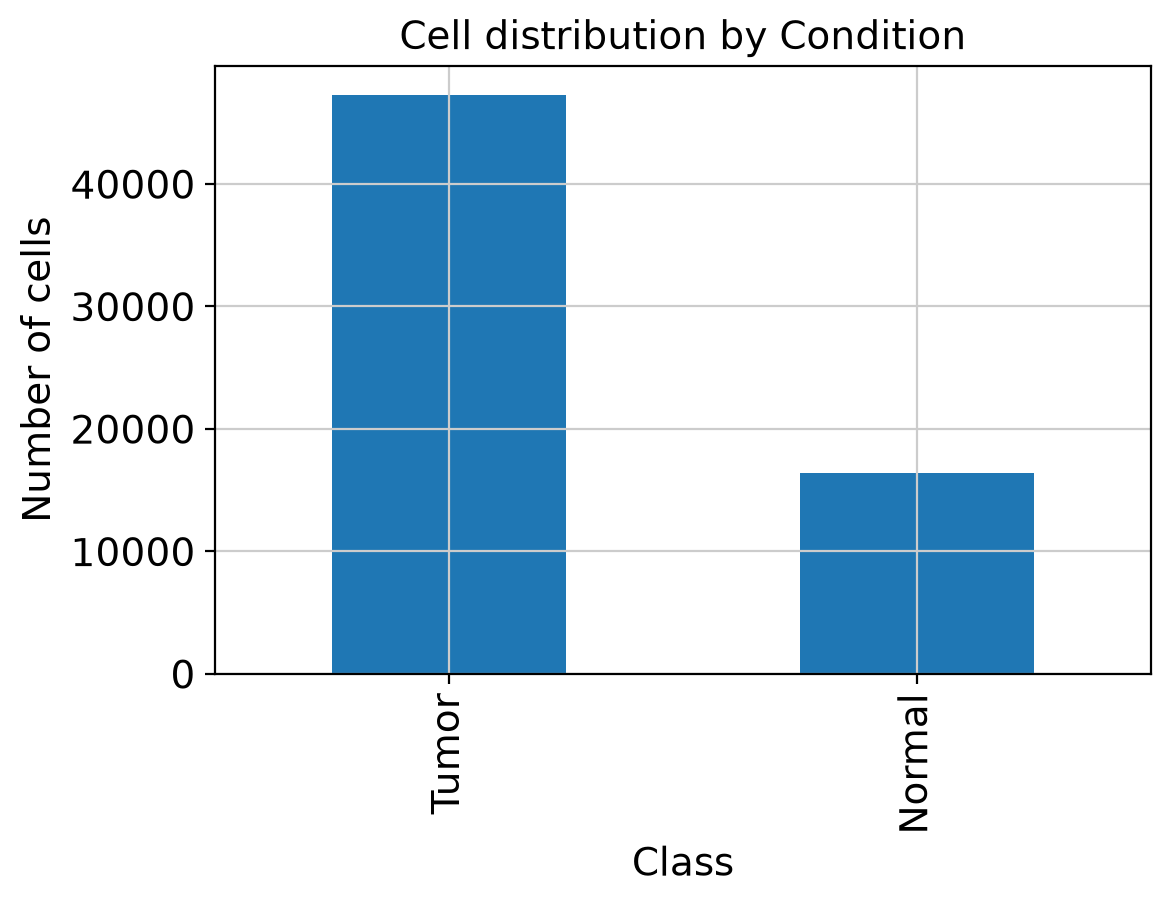

In [9]:
import matplotlib.pyplot as plt

adata.obs["Class"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("Number of cells")
plt.title("Cell distribution by Condition")
plt.show()

Cell_type
T cells             23115
Epithelial cells    18539
B cells              9146
Myeloids             6769
Stromal cells        5933
Mast cells            187
Name: count, dtype: int64


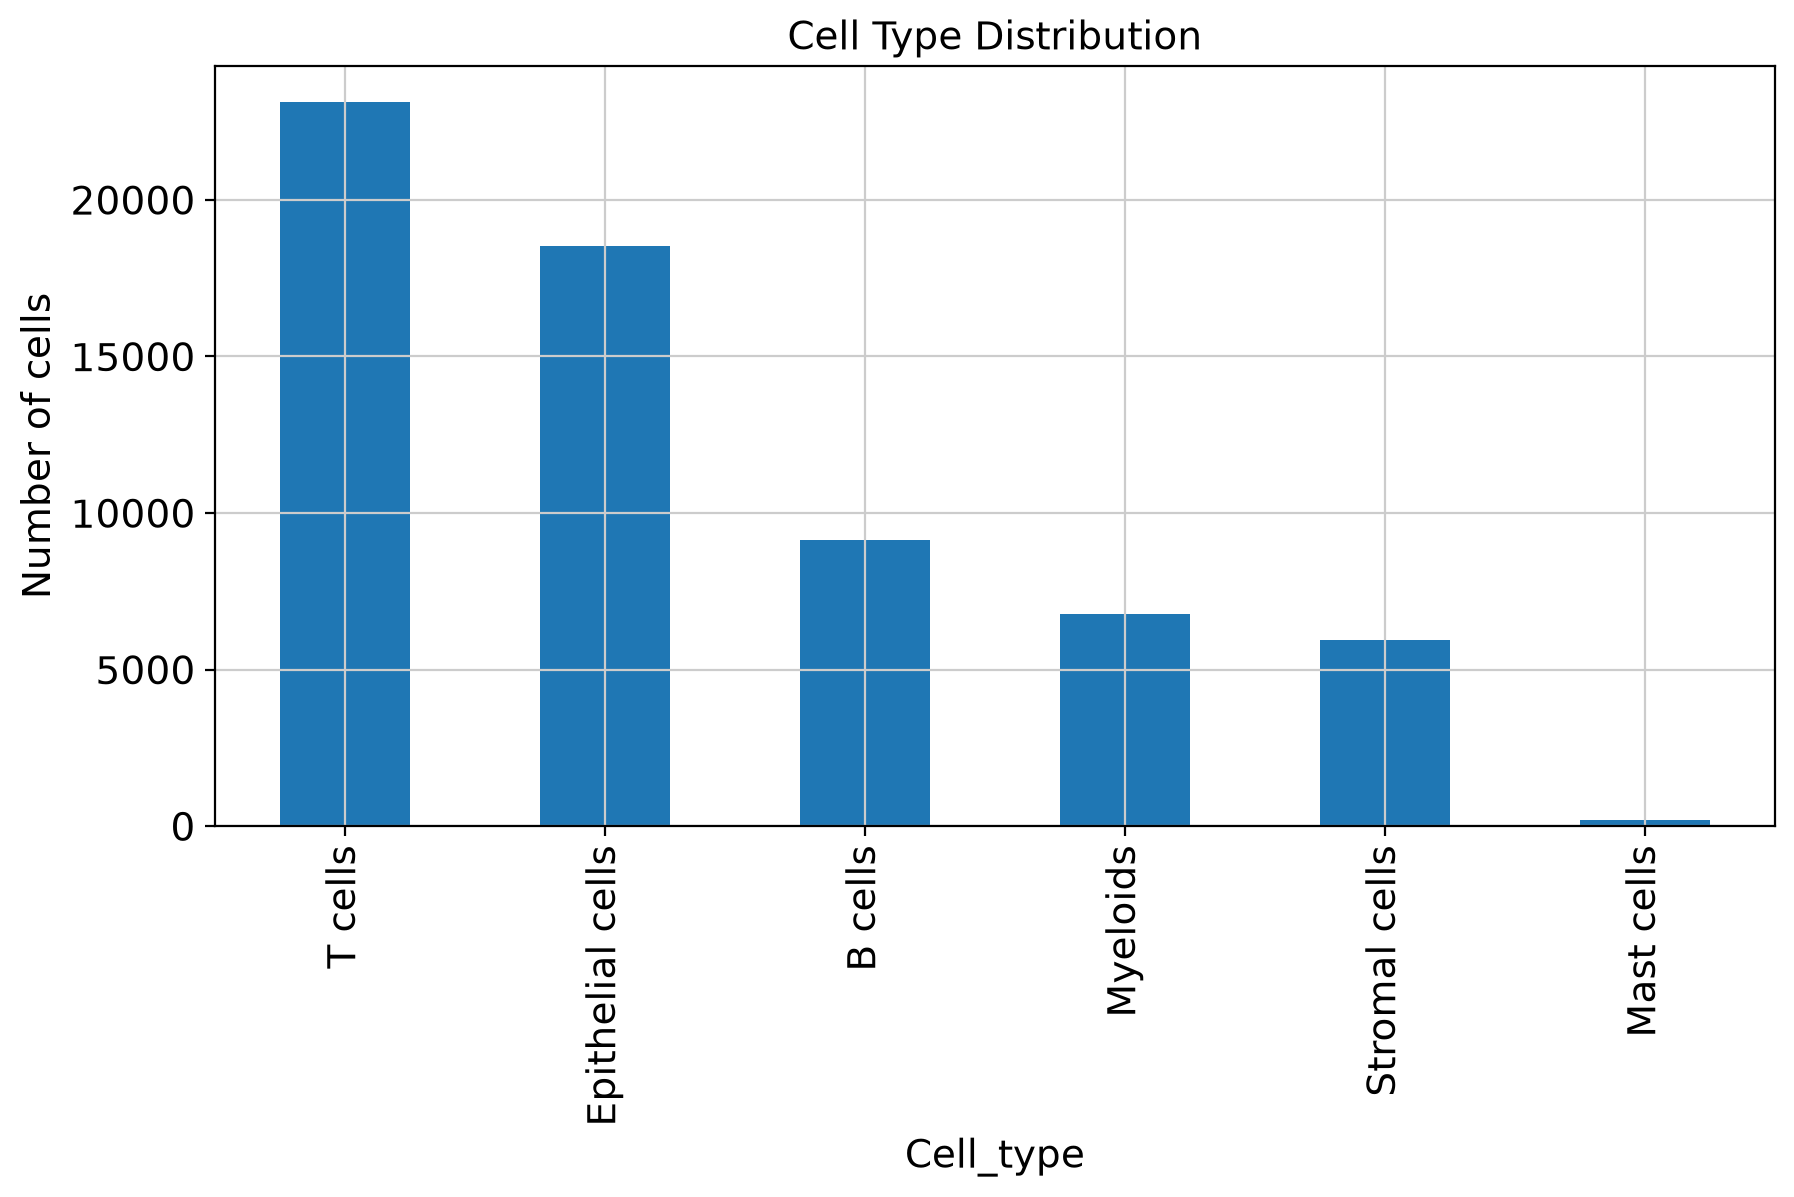

In [12]:
cell_counts = adata.obs["Cell_type"].value_counts()

print(cell_counts)

plt.figure(figsize=(10,5))

cell_counts.plot(kind="bar")

plt.xticks(rotation=90)
plt.ylabel("Number of cells")
plt.title("Cell Type Distribution")

plt.show()

Cell_subtype
CMS2                         10771
CD4+ T cells                  7305
CD8+ T cells                  6404
CMS3                          5486
CD19+CD20+ B                  3733
IgA+ Plasma                   3546
SPP1+                         3252
Regulatory T cells            3097
Pro-inflammatory              2399
Unknown                       2181
T helper 17 cells             1978
IgG+ Plasma                   1755
CMS1                          1201
Myofibroblasts                1155
NK cells                      1111
Stromal 1                     1045
gamma delta T cells            996
Tip-like ECs                   917
Stromal 3                      868
T follicular helper cells      620
cDC                            482
Pericytes                      445
Stalk-like ECs                 438
Stem-like/TA                   406
Stromal 2                      394
Enteric glial cells            305
Smooth muscle cells            214
Mature Enterocytes type 1      213
Mast ce

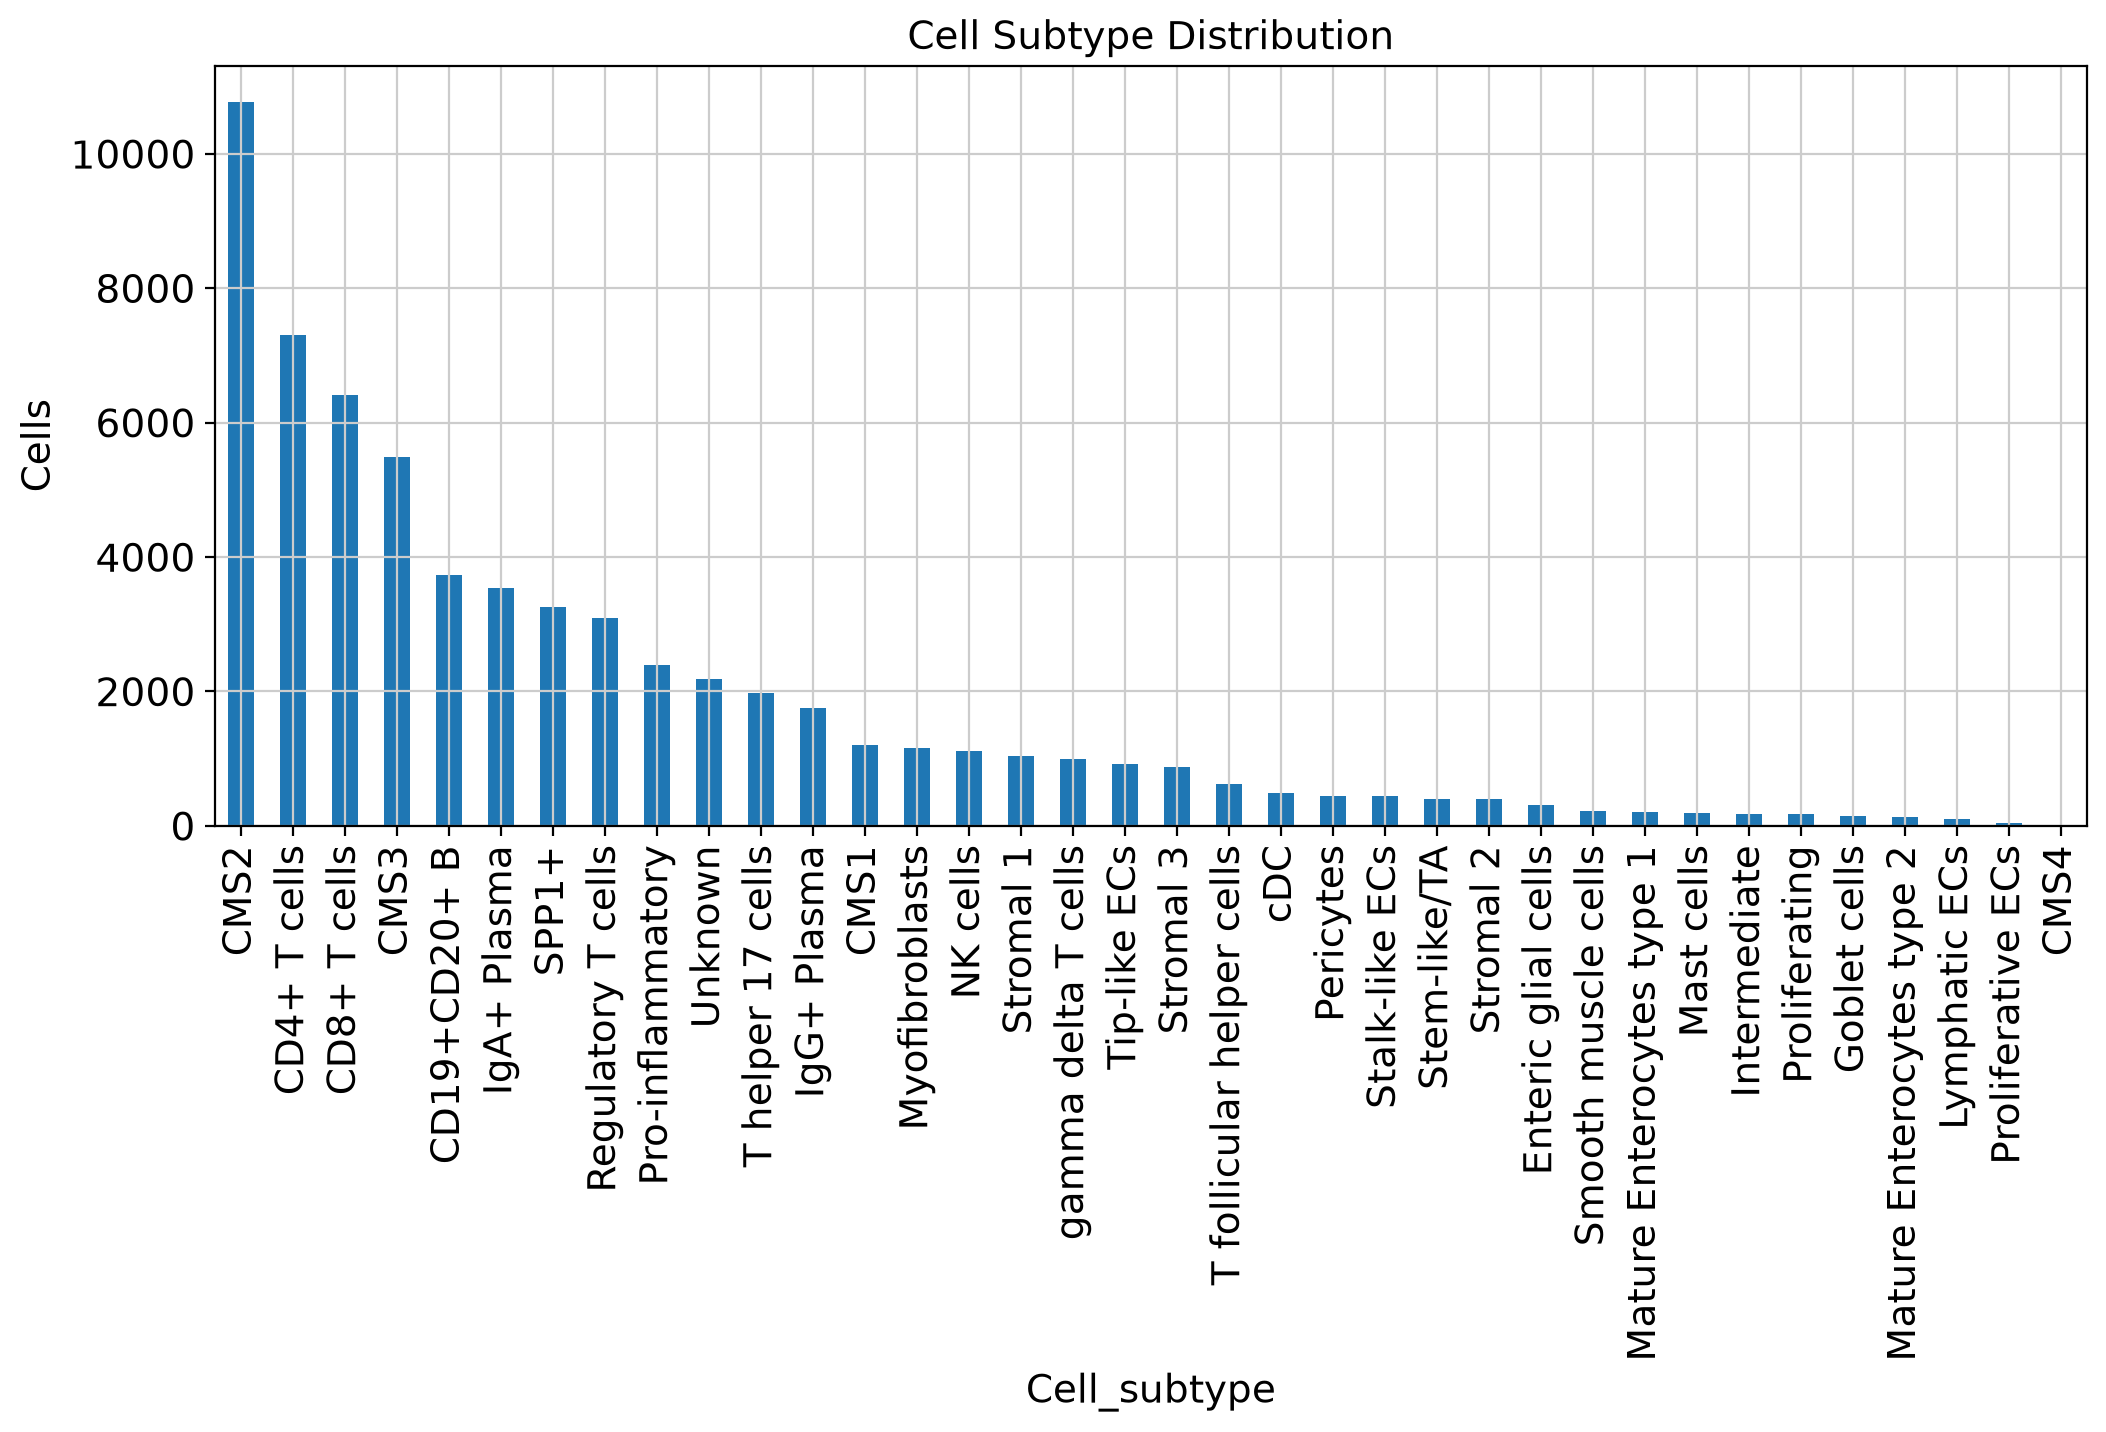

In [15]:
subtype_counts = adata.obs["Cell_subtype"].value_counts()

print(subtype_counts)

plt.figure(figsize=(12,5))

subtype_counts.plot(kind="bar")

plt.xticks(rotation=90)
plt.ylabel("Cells")
plt.title("Cell Subtype Distribution")

plt.show()

In [5]:
# ============================================================
# 3. QC metrics
# ============================================================

adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains(r"^HB[^P]", regex=True)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=[20],
    log1p=True,
    inplace=True,
)

qc_cols = [
    "total_counts",
    "n_genes_by_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb",
    "pct_counts_in_top_20_genes",
]

print(adata.obs[qc_cols].describe().T)

                              count         mean           std          min  \
total_counts                63689.0  9776.717773  10874.748047  1001.000000   
n_genes_by_counts           63689.0  1880.315565   1386.370488   201.000000   
pct_counts_mt               63689.0     5.719263      4.049578     0.000000   
pct_counts_ribo             63689.0    26.649433     11.433534     0.695825   
pct_counts_hb               63689.0     0.011790      0.266652     0.000000   
pct_counts_in_top_20_genes  63689.0    30.224669     14.477955    10.107618   

                                    25%          50%           75%  \
total_counts                2435.000000  4259.000000  14508.000000   
n_genes_by_counts            873.000000  1265.000000   2658.000000   
pct_counts_mt                  2.894388     4.518072      7.434139   
pct_counts_ribo               18.162807    26.958212     34.846001   
pct_counts_hb                  0.000000     0.000000      0.011898   
pct_counts_in_top_20_genes

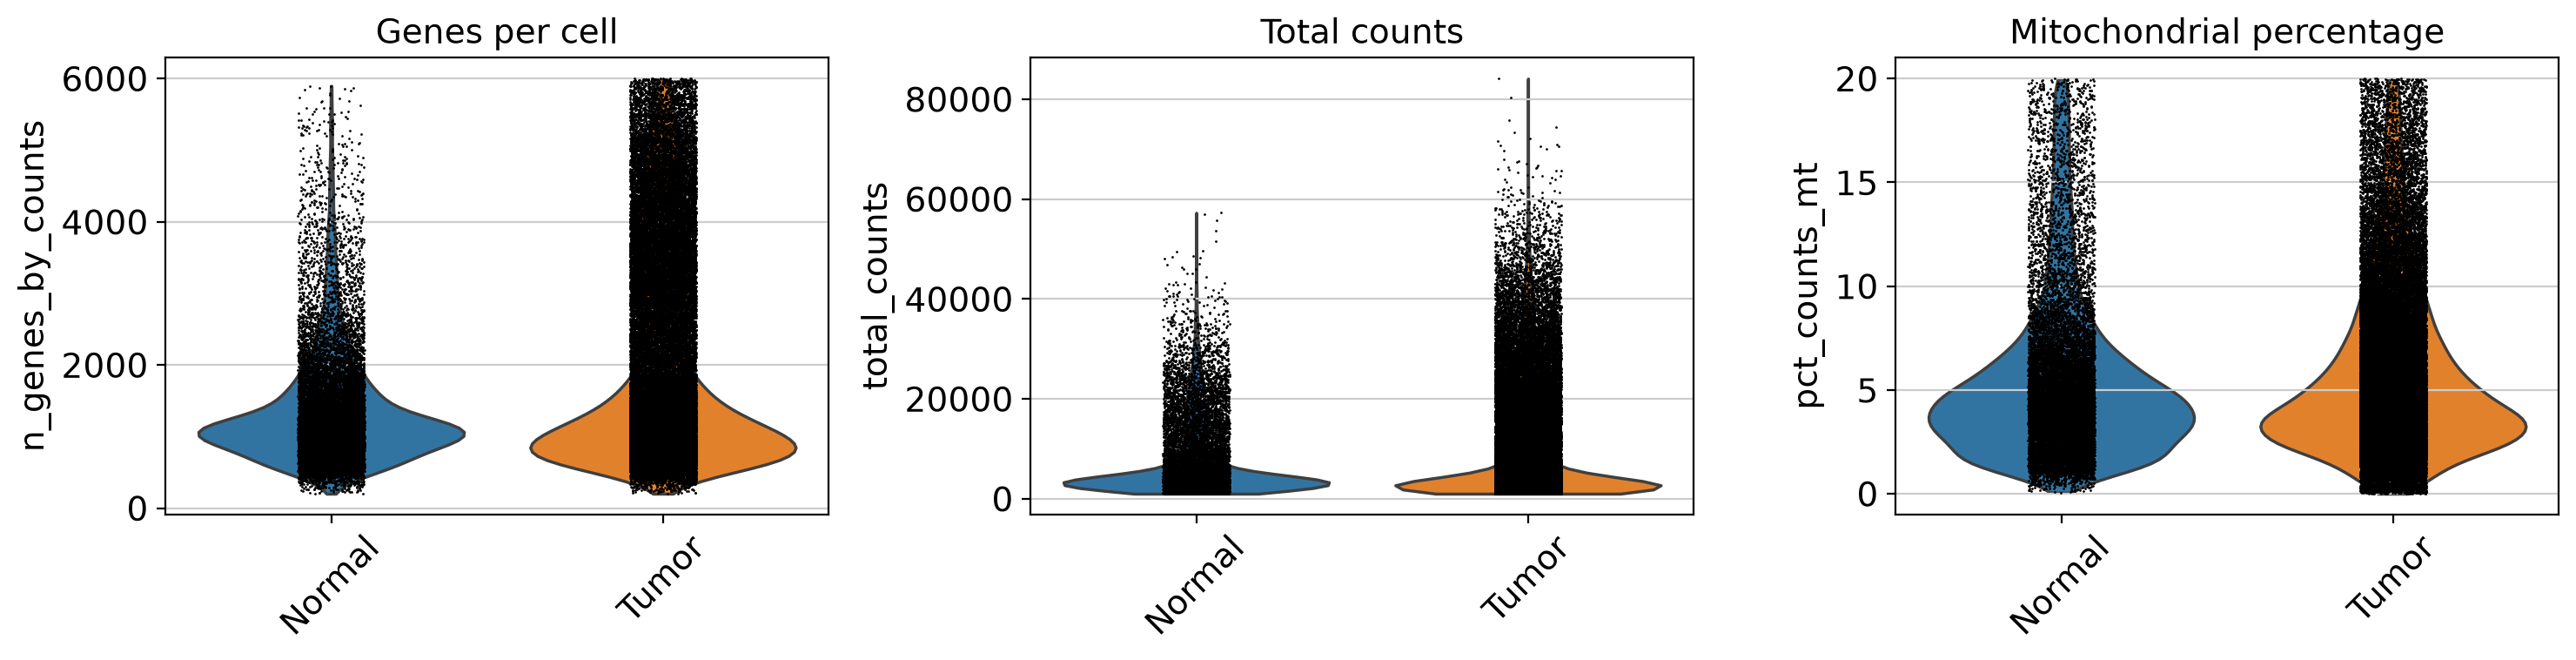

In [6]:
# ============================================================
# 4. QC plots before filtering
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc.pl.violin(
    adata,
    keys="n_genes_by_counts",
    groupby=class_col,
    ax=axes[0],
    show=False,
    rotation=45
)
axes[0].set_title("Genes per cell")

sc.pl.violin(
    adata,
    keys="total_counts",
    groupby=class_col,
    ax=axes[1],
    show=False,
    rotation=45
)
axes[1].set_title("Total counts")

sc.pl.violin(
    adata,
    keys="pct_counts_mt",
    groupby=class_col,
    ax=axes[2],
    show=False,
    rotation=45
)
axes[2].set_title("Mitochondrial percentage")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "qc_violin_before_filtering.png"), dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ============================================================
# 5. Light-touch, composition-aware MAD QC filtering  (v3)
# ============================================================
# The deposited matrix is already QC-filtered by the original authors
# (min 1,000 UMI, min 200 genes, pct_mt < 20 — confirmed by the describe table:
# total_counts min = 1,001, n_genes min = 201, pct_counts_mt max = 19.99).
# An additional mitochondrial filter is therefore redundant, and empirically it is
# lineage-biased: normal mature colonocytes are metabolically active and carry a
# physiologically high mitochondrial fraction, so an MT rule preferentially deletes
# the NORMAL epithelial compartment — the exact contrast this study models.
# We therefore disable it and rely on the authors' 20% cap.

MT_RULE = "off"        # "off" (recommended) | "mad"
NMADS_MT = 5           # only used when MT_RULE == "mad"

def is_outlier(values, nmads):
    v   = pd.Series(values).astype(float)
    med = np.median(v)
    mad = median_abs_deviation(v, nan_policy="omit")
    if mad == 0:
        return pd.Series(False, index=v.index)
    return (v < med - nmads * mad) | (v > med + nmads * mad)

def is_outlier_by_group(ad, metric, nmads, group_col):
    """MAD rule computed WITHIN each cell type (label-blind, lineage-aware)."""
    out = pd.Series(False, index=ad.obs_names)
    for g, idx in ad.obs.groupby(group_col, observed=True).groups.items():
        sub = ad.obs.loc[idx, metric]
        if len(sub) < 20:
            continue
        out.loc[idx] = is_outlier(sub, nmads).values
    return out

# --- rule 1: library size / complexity (global) ---
adata.obs["outlier_counts"] = (
    is_outlier(adata.obs["log1p_total_counts"], NMADS_COUNTS).values
    | is_outlier(adata.obs["log1p_n_genes_by_counts"], NMADS_COUNTS).values
)

# --- rule 2: transcriptome dominance, WITHIN cell type ---
adata.obs["outlier_top20"] = is_outlier_by_group(
    adata, "pct_counts_in_top_20_genes", NMADS_TOP20, celltype_col
).values

# --- rule 3: mitochondrial fraction (disabled by default) ---
if MT_RULE == "mad":
    adata.obs["mt_outlier"] = is_outlier(adata.obs["pct_counts_mt"], NMADS_MT).values
else:
    adata.obs["mt_outlier"] = False
    print("MT rule DISABLED (source matrix already capped at 20% MT).")


adata.obs["qc_fail"] = (adata.obs["outlier_counts"]
                        | adata.obs["outlier_top20"]
                        | adata.obs["mt_outlier"])

# ---------- PER-RULE ATTRIBUTION AUDIT ----------
print("\nCells flagged by each rule, by cell type x class (% of that group):")
for rule in ["outlier_counts", "outlier_top20", "mt_outlier", "qc_fail"]:
    if not adata.obs[rule].any():
        print(f"\n[{rule}] flags nothing.")
        continue
    tab = (adata.obs.groupby([celltype_col, class_col], observed=True)[rule]
           .mean().unstack(fill_value=0) * 100).round(1)
    print(f"\n[{rule}] total = {int(adata.obs[rule].sum()):,}")
    print(tab)

print("\nBefore QC filtering:", f"{adata.n_obs:,}")

qc_before_df = adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].copy()
qc_before_df["stage"] = "Before QC"

adata = adata[~adata.obs["qc_fail"]].copy()

qc_after_df = adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].copy()
qc_after_df["stage"] = "After QC"

print(f"After QC filtering: {adata.n_obs:,} "
      f"({100 * adata.n_obs / len(qc_before_df):.1f}% retained)")

MT rule DISABLED (source matrix already capped at 20% MT).

Cells flagged by each rule, by cell type x class (% of that group):

[outlier_counts] flags nothing.

[outlier_top20] total = 1,615
Class             Normal  Tumor
Cell_type                      
B cells              0.0    0.0
Epithelial cells    36.7    3.2
Mast cells           0.0    0.0
Myeloids             0.5    3.6
Stromal cells        5.3    4.3
T cells              0.9    0.5

[mt_outlier] flags nothing.

[qc_fail] total = 1,615
Class             Normal  Tumor
Cell_type                      
B cells              0.0    0.0
Epithelial cells    36.7    3.2
Mast cells           0.0    0.0
Myeloids             0.5    3.6
Stromal cells        5.3    4.3
T cells              0.9    0.5

Before QC filtering: 63,689
After QC filtering: 62,074 (97.5% retained)


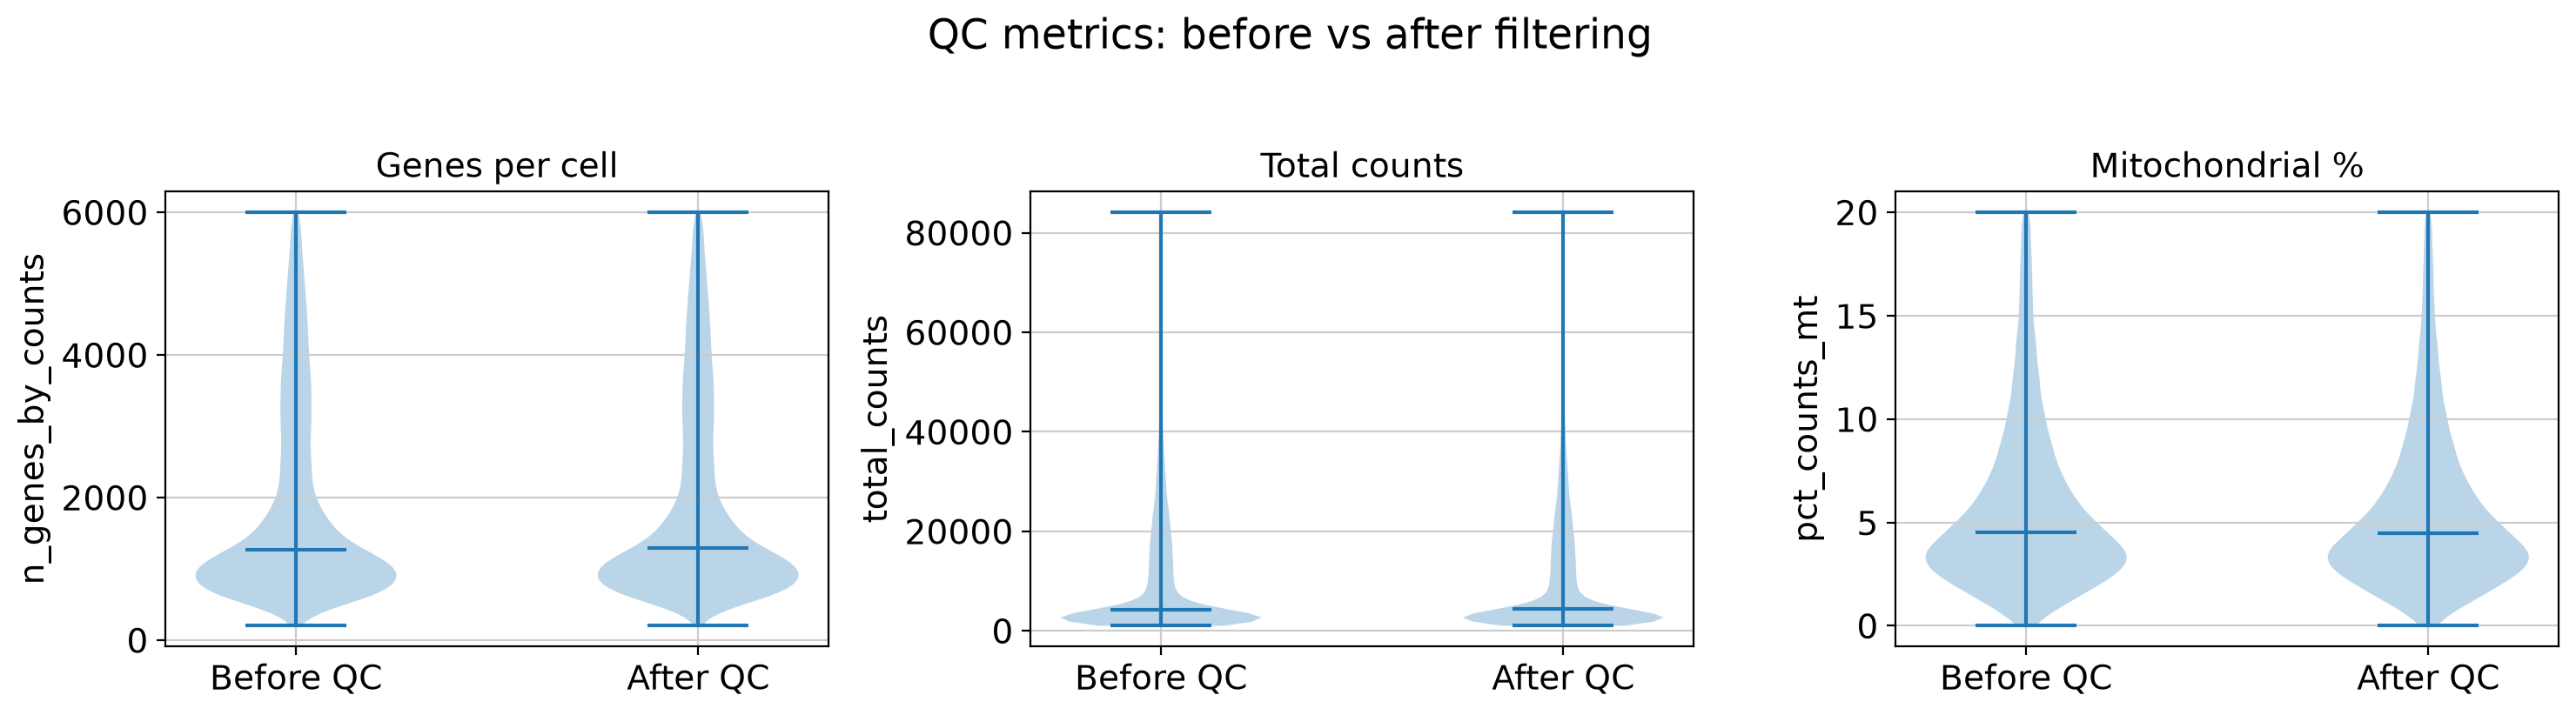

Cell-type x class retention after QC (%):
Class             Normal  Tumor
Cell_type                      
B cells            100.0  100.0
Epithelial cells    63.3   96.8
Mast cells         100.0  100.0
Myeloids            99.5   96.4
Stromal cells       94.7   95.7
T cells             99.1   99.5

Global tumor fraction  pre-QC: 0.742  |  post-QC: 0.746

Retention spread = 37 pp — acceptable, QC is near-uniform.


In [8]:
# ============================================================
# 5b. QC before/after + DIFFERENTIAL-LOSS AUDIT
# ============================================================
qc_compare = pd.concat([qc_before_df, qc_after_df], ignore_index=True)
metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
titles  = ["Genes per cell", "Total counts", "Mitochondrial %"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, title in zip(axes, metrics, titles):
    b = qc_compare.loc[qc_compare["stage"] == "Before QC", metric].values
    a = qc_compare.loc[qc_compare["stage"] == "After QC",  metric].values
    ax.violinplot([b, a], showmedians=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Before QC", "After QC"])
    ax.set_title(title); ax.set_ylabel(metric)
plt.suptitle("QC metrics: before vs after filtering", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "qc_before_vs_after_filtering.png"),
            dpi=300, bbox_inches="tight")
plt.show()

# ---------- differential-loss audit (reviewer-facing) ----------
comp_after = pd.crosstab(adata.obs[celltype_col], adata.obs[class_col])
comp_after = comp_after.reindex(index=comp_before.index,
                                columns=comp_before.columns, fill_value=0)

retained_pct = (comp_after / comp_before.replace(0, np.nan) * 100).round(1)
audit = pd.concat({"pre_QC": comp_before, "post_QC": comp_after,
                   "retained_%": retained_pct}, axis=1)
audit.to_csv(os.path.join(OUT_DIR, "composition_QC_audit.csv"))

print("Cell-type x class retention after QC (%):")
print(retained_pct)
print("\nGlobal tumor fraction  pre-QC: "
      f"{comp_before['Tumor'].sum() / comp_before.values.sum():.3f}"
      f"  |  post-QC: {comp_after['Tumor'].sum() / comp_after.values.sum():.3f}")

# hard guard: refuse to continue if QC is class-differential
spread = retained_pct.max().max() - retained_pct.min().min()
if spread > 40:
    print(f"\n*** WARNING: retention spread = {spread:.0f} percentage points. "
          "QC is class/lineage-differential — loosen the thresholds. ***")
else:
    print(f"\nRetention spread = {spread:.0f} pp — acceptable, QC is near-uniform.")

In [9]:
# ============================================================
# 6. Gene filtering
# ============================================================

print("Before gene filtering:", adata.n_vars)
sc.pp.filter_genes(adata, min_cells=3)
print("After gene filtering:", adata.n_vars)

# Keep counts layer aligned after filtering
if "counts" not in adata.layers:
    raise ValueError("counts layer missing.")

Before gene filtering: 33694


filtered out 8071 genes that are detected in less than 3 cells
After gene filtering: 25623


In [10]:
# ============================================================
# 6b. Artifact-gene removal (BEFORE HVG) + dissociation-IEG flagging
# ============================================================
import re

HB_GENES  = {"HBA1","HBA2","HBB","HBD","HBG1","HBG2","HBM","HBQ1","HBZ","HBE1"}
SEX_GENES = {"XIST","TSIX","RPS4Y1","RPS4Y2","DDX3Y","UTY","USP9Y",
             "EIF1AY","KDM5D","NLGN4Y","ZFY","TXLNGY","PRKY"}
LNC_GENES = {"MALAT1","NEAT1"}
HSP_KEEP  = {"HSPG2"}     # perlecan = real ECM gene, NOT a chaperone

# Canonical tissue-dissociation immediate-early genes (van den Brink 2017,
# O'Flanagan 2019). FLAGGED, NOT DELETED — notebook 04 toggles them so that a
# sensitivity analysis can show the panel is not driven by dissociation stress.
# Deliberately EXCLUDED from this list (genuine cancer biology): MYC, MCL1,
# ID1/2/3, SGK1, NFKBIA, TNFAIP3, RGS1.
DISSOCIATION_IEG = {
    "FOS","FOSB","JUN","JUNB","JUND","EGR1","EGR2","EGR3","ATF3",
    "IER2","IER3","DUSP1","NR4A1","NR4A2","NR4A3","ZFP36",
    "KLF2","KLF4","KLF6","SOCS3","PPP1R15A","GADD45B",
    "CYR61","CCN1","BTG2","RHOB","PER1","ZNF331","CEBPB","CEBPD",
}

def is_artifact_gene(g):
    g = str(g)
    if g.startswith("MT-"):                                   return True   # mitochondrial
    if g.startswith(("RPS","RPL","MRPS","MRPL")):             return True   # ribosomal
    if re.match(r"^IG[HKL](V|D|J|C|A|G|M|E)", g) or g == "JCHAIN" or g.startswith("IGLL"):
        return True                                                          # immunoglobulin
    if g in HB_GENES:                                         return True   # hemoglobin
    if (g.startswith("HSP") and g not in HSP_KEEP) or g.startswith("DNAJ"):
        return True                                                          # heat-shock (HSPH1 now caught)
    if g in SEX_GENES:                                        return True   # sex chromosome
    if g in LNC_GENES:                                        return True   # nuclear lncRNA
    return False

def drop_artifact_genes(ad, verbose=True):
    keep    = np.array([not is_artifact_gene(g) for g in ad.var_names])
    removed = ad.var_names[~keep].tolist()
    if verbose:
        fam = {"MT-":0,"RP(S/L)":0,"IG":0,"HB":0,"HSP/DNAJ":0,"sex":0,"lncRNA":0}
        for g in removed:
            if   g.startswith("MT-"):                          fam["MT-"] += 1
            elif g.startswith(("RPS","RPL","MRPS","MRPL")):     fam["RP(S/L)"] += 1
            elif g.startswith(("IGH","IGK","IGL")) or g == "JCHAIN": fam["IG"] += 1
            elif g in HB_GENES:                                fam["HB"] += 1
            elif g.startswith("HSP") or g.startswith("DNAJ"):   fam["HSP/DNAJ"] += 1
            elif g in SEX_GENES:                               fam["sex"] += 1
            elif g in LNC_GENES:                               fam["lncRNA"] += 1
        print(f"Artifact genes removed: {int((~keep).sum())} of {ad.n_vars}. "
              f"Remaining: {int(keep.sum())}")
        print("  by family:", {k: v for k, v in fam.items() if v})
        print("  HSPH1 removed:", "HSPH1" in removed)   # regression check for the old bug
    return ad[:, keep].copy()

adata = drop_artifact_genes(adata, verbose=True)

# --- flag (do NOT remove) dissociation IEGs ---
adata.var["dissociation_ieg"] = [g in DISSOCIATION_IEG for g in adata.var_names]
n_ieg = int(adata.var["dissociation_ieg"].sum())
print(f"\nDissociation IEGs flagged (kept in matrix): {n_ieg}")
print("  present:", sorted(adata.var_names[adata.var['dissociation_ieg']].tolist()))

pd.DataFrame({"gene": sorted(adata.var_names[adata.var["dissociation_ieg"]])}
             ).to_csv(os.path.join(OUT_DIR, "dissociation_IEG_genes.csv"), index=False)
print("Gene space after artifact removal:", adata.n_vars)

Artifact genes removed: 466 of 25623. Remaining: 25157
  by family: {'MT-': 13, 'RP(S/L)': 179, 'IG': 176, 'HB': 8, 'HSP/DNAJ': 79, 'sex': 9, 'lncRNA': 2}
  HSPH1 removed: True

Dissociation IEGs flagged (kept in matrix): 29
  present: ['ATF3', 'BTG2', 'CEBPB', 'CEBPD', 'CYR61', 'DUSP1', 'EGR1', 'EGR2', 'EGR3', 'FOS', 'FOSB', 'GADD45B', 'IER2', 'IER3', 'JUN', 'JUNB', 'JUND', 'KLF2', 'KLF4', 'KLF6', 'NR4A1', 'NR4A2', 'NR4A3', 'PER1', 'PPP1R15A', 'RHOB', 'SOCS3', 'ZFP36', 'ZNF331']
Gene space after artifact removal: 25157


In [11]:
# ============================================================
# 7. Doublet detection using Scrublet per sample
# ============================================================

# Scrublet should run before normalization and on raw count-like data.
# Current adata.X is still raw counts here.

print("Running Scrublet per sample...")
sc.pp.scrublet(
    adata,
    batch_key=sample_col,
    random_state=RANDOM_STATE
)

print("Predicted doublets:")
print(adata.obs["predicted_doublet"].value_counts())

adata = adata[~adata.obs["predicted_doublet"]].copy()

print("After doublet removal:", adata.n_obs)

Running Scrublet per sample...
Running Scrublet
filtered out 8234 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:01)
Embedding transcriptomes using PCA...
    using data matrix X directly
Automatically set threshold at doublet score = 0.34
Detected doublet rate = 0.2%
Estimated detectable doublet fraction = 22.4%
Overall doublet rate:
	Expected   = 5.0%
	Estimated  = 0.8%
filtered out 7662 genes that are detected in less than 3 cells
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
 

In [12]:
# ============================================================
# 8. Normalize and log-transform
# ============================================================

# Save raw count layer before modifying X
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# adata.X is now log-normalized expression
print("Normalization + log1p complete.")
print(adata)

normalizing counts per cell
    finished (0:00:00)
Normalization + log1p complete.
AnnData object with n_obs × n_vars = 61948 × 25157
    obs: 'Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier_counts', 'outlier_top20', 'mt_outlier', 'qc_fail', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'dissociation_ieg'
    uns: 'Class_colors', 'scrublet', 'log1p'
    layers: None (.X), 'counts'


extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)
HVGs selected: 3,000 / 25,157
Dissociation IEGs inside the HVG set: 20 (excluded in the primary Option B model, retained for sensitivity analysis)


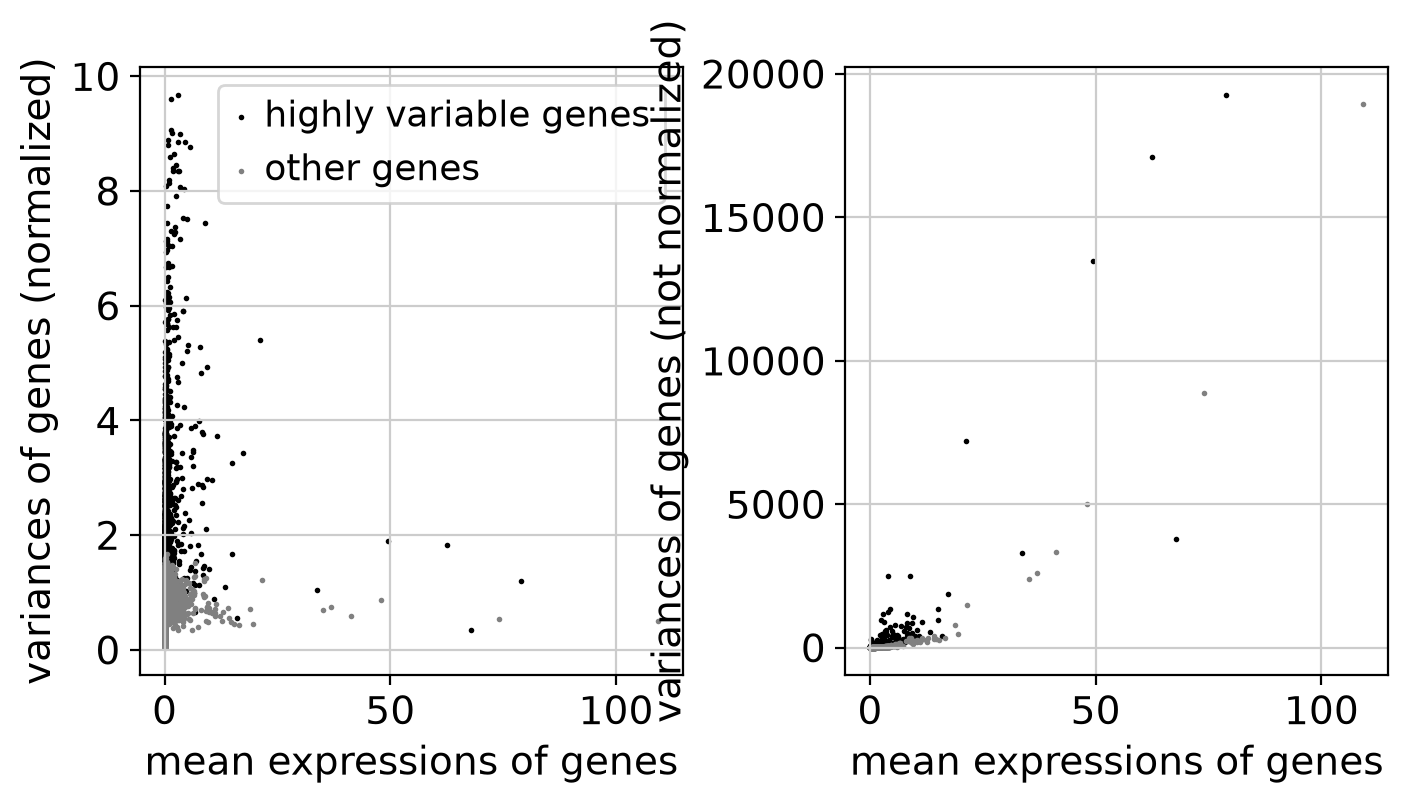

In [13]:
# ============================================================
# 7. HVG selection, batch-aware (label-blind, therefore leakage-free)
# ============================================================
sc.pp.highly_variable_genes(
    adata, n_top_genes=N_TOP_HVG, batch_key=patient_col,
    flavor="seurat_v3", layer="counts", subset=False
)

n_hvg = int(adata.var["highly_variable"].sum())
print(f"HVGs selected: {n_hvg:,} / {adata.n_vars:,}")

hvg_mask = adata.var["highly_variable"].values
n_ieg_hvg = int((hvg_mask & adata.var["dissociation_ieg"].values).sum())
print(f"Dissociation IEGs inside the HVG set: {n_ieg_hvg} "
      "(excluded in the primary Option B model, retained for sensitivity analysis)")

hvg_genes = adata.var_names[hvg_mask].to_list()
pd.DataFrame({
    "gene": hvg_genes,
    "dissociation_ieg": adata.var.loc[hvg_genes, "dissociation_ieg"].values
}).to_csv(os.path.join(OUT_DIR, "GSE132465_HVG3000_gene_list.csv"), index=False)

sc.pl.highly_variable_genes(adata, show=False)
plt.savefig(os.path.join(FIG_DIR, "hvg_plot.png"), dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# ============================================================
# 10. Cell type and class summary after preprocessing
# ============================================================

celltype_class_counts = pd.crosstab(
    adata.obs[celltype_col],
    adata.obs[class_col]
)

celltype_patient_counts = (
    adata.obs
    .groupby([celltype_col, class_col], observed=True)[patient_col]
    .nunique()
    .unstack(fill_value=0)
)

celltype_sample_counts = (
    adata.obs
    .groupby([celltype_col, class_col], observed=True)[sample_col]
    .nunique()
    .unstack(fill_value=0)
)

print("Cell counts by cell type and class:")
display(celltype_class_counts)

print("\nPatient/group counts by cell type and class:")
display(celltype_patient_counts)

print("\nSample counts by cell type and class:")
display(celltype_sample_counts)

celltype_class_counts.to_csv(os.path.join(OUT_DIR, "celltype_class_cell_counts.csv"))
celltype_patient_counts.to_csv(os.path.join(OUT_DIR, "celltype_class_patient_counts.csv"))
celltype_sample_counts.to_csv(os.path.join(OUT_DIR, "celltype_class_sample_counts.csv"))

Cell counts by cell type and class:


Class,Normal,Tumor
Cell_type,,
B cells,5177,3933
Epithelial cells,670,16877
Mast cells,183,3
Myeloids,367,6159
Stromal cells,3021,2617
T cells,6312,16629



Patient/group counts by cell type and class:


Class,Normal,Tumor
Cell_type,,
B cells,10,23
Epithelial cells,10,23
Mast cells,10,2
Myeloids,10,23
Stromal cells,10,23
T cells,10,23



Sample counts by cell type and class:


Class,Normal,Tumor
Cell_type,,
B cells,10,23
Epithelial cells,10,23
Mast cells,10,2
Myeloids,10,23
Stromal cells,10,23
T cells,10,23


In [15]:
# ============================================================
# 11. Save DL-ready object for Option B
# ============================================================
import anndata
anndata.settings.allow_write_nullable_strings = True   # <-- the real fix

DL_OUT = os.path.join(OUT_DIR, "GSE132465_DL_ready_HVG3000_celllevel.h5ad")

adata_dl = adata.copy()

keep_obs = [c for c in [class_col, celltype_col, patient_col, sample_col,
                        "total_counts", "n_genes_by_counts", "pct_counts_mt"]
            if c in adata_dl.obs.columns]
adata_dl.obs = adata_dl.obs[keep_obs].copy()

adata_dl.write_h5ad(DL_OUT)
print("Saved DL-ready object:", DL_OUT)
print(adata_dl)
print("\nHVG count in saved object:", int(adata_dl.var["highly_variable"].sum()))
print("X is log-normalized (unscaled). Harmony PCs intentionally excluded.")

print("dissociation_ieg flag saved in .var:",
      "dissociation_ieg" in adata_dl.var.columns,
      "| count:", int(adata_dl.var["dissociation_ieg"].sum()))

Saved DL-ready object: gse132465_preprocessing_outputs_before_Xm/GSE132465_DL_ready_HVG3000_celllevel.h5ad
AnnData object with n_obs × n_vars = 61948 × 25157
    obs: 'Class', 'Cell_type', 'Patient', 'Sample', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'dissociation_ieg', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Class_colors', 'scrublet', 'log1p', 'hvg'
    layers: None (.X), 'counts'

HVG count in saved object: 3000
X is log-normalized (unscaled). Harmony PCs intentionally excluded.
dissociation_ieg flag saved in .var: True | count: 29


## Harmony UMAP visualization

The following section creates UMAP/clustering plots **before and after Harmony** for 6 major cell types.

This visualization object is separate from the DL-ready object. It uses scaled HVG expression for PCA/UMAP, while the DL-ready object remains log-normalized and unscaled.

In [16]:
# ============================================================
# 12. Prepare visualization object: 6 major cell types and HVGs only
# ============================================================

target_celltypes = [
    "T cells",
    "Epithelial cells",
    "B cells",
    "Myeloids",
    "Stromal cells",
    "Mast cells"
]

existing_celltypes = [ct for ct in target_celltypes if ct in adata.obs[celltype_col].unique()]
missing_celltypes = [ct for ct in target_celltypes if ct not in adata.obs[celltype_col].unique()]

print("Using cell types:", existing_celltypes)
if missing_celltypes:
    print("Missing cell types:", missing_celltypes)

# Visualization object: only selected cell types and HVGs
adata_viz = adata[
    adata.obs[celltype_col].isin(existing_celltypes),
    adata.var["highly_variable"]
].copy()

for col in [celltype_col, class_col, sample_col, patient_col]:
    if col in adata_viz.obs.columns:
        adata_viz.obs[col] = adata_viz.obs[col].astype("category")

print(adata_viz)
print("\nCell type distribution:")
print(adata_viz.obs[celltype_col].value_counts())

print("\nClass distribution:")
print(adata_viz.obs[class_col].value_counts())

print("\nSample count:", adata_viz.obs[sample_col].nunique())

Using cell types: ['T cells', 'Epithelial cells', 'B cells', 'Myeloids', 'Stromal cells', 'Mast cells']
AnnData object with n_obs × n_vars = 61948 × 3000
    obs: 'Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier_counts', 'outlier_top20', 'mt_outlier', 'qc_fail', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'dissociation_ieg', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'Class_colors', 'scrublet', 'log1p', 'hvg'
    layers: None (.X), 

In [17]:
# ============================================================
# 13. Scale HVGs for PCA only
# ============================================================

# Scaling is done only on adata_viz, not on the DL-ready adata_hvg object.
sc.pp.scale(adata_viz, max_value=10)

print("Scaled visualization object for PCA.")
print(adata_viz)

Scaled visualization object for PCA.
AnnData object with n_obs × n_vars = 61948 × 3000
    obs: 'Patient', 'Class', 'Sample', 'Cell_type', 'Cell_subtype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier_counts', 'outlier_top20', 'mt_outlier', 'qc_fail', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'dissociation_ieg', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'Class_colors', 'scrublet', 'log1p', 'hvg'
    layers: None (.X), 'counts'


In [19]:
# ============================================================
# 14. BEFORE Harmony: PCA, neighbors, Leiden, UMAP
# ============================================================

sc.tl.pca(
    adata_viz,
    n_comps=50,
    svd_solver="arpack",
    random_state=RANDOM_STATE
)

print("X_pca shape:", adata_viz.obsm["X_pca"].shape)

sc.pp.neighbors(
    adata_viz,
    n_neighbors=15,
    n_pcs=30,
    use_rep="X_pca",
    key_added="neighbors_before_harmony",
    random_state=RANDOM_STATE
)

sc.tl.leiden(
    adata_viz,
    resolution=0.6,
    neighbors_key="neighbors_before_harmony",
    key_added="leiden_before_harmony",
    random_state=RANDOM_STATE
)

sc.tl.umap(
    adata_viz,
    neighbors_key="neighbors_before_harmony",
    random_state=RANDOM_STATE
)

adata_viz.obsm["X_umap_before_harmony"] = adata_viz.obsm["X_umap"].copy()

print("Before Harmony complete.")
print(adata_viz.obs["leiden_before_harmony"].value_counts().sort_index())

computing PCA
    with n_comps=50
    finished (0:00:06)
X_pca shape: (61948, 50)
computing neighbors
    finished: added to `.uns['neighbors_before_harmony']`
    `.obsp['neighbors_before_harmony_distances']`, distances for each pair of neighbors
    `.obsp['neighbors_before_harmony_connectivities']`, weighted adjacency matrix (0:00:02)
running Leiden clustering
    finished: found 25 clusters and added
    'leiden_before_harmony', the cluster labels (adata.obs, categorical) (0:01:10)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:06)
Before Harmony complete.
leiden_before_harmony
0     9788
1     8341
2     5361
3     4526
4     3746
5     3436
6     3091
7     2877
8     2665
9     2340
10    2193
11    1798
12    1693
13    1621
14    1458
15    1433
16    1315
17    1252
18     774
19     746
20     480
21     294
22     284
23     250
24     186
Name: count, dtype: int64


In [20]:
# ============================================================
# 15. AFTER Harmony: robust direct harmonypy integration
# ============================================================

if hm is None:
    raise ImportError("harmonypy is not installed. Run: !pip install harmonypy -q")

if "X_pca" not in adata_viz.obsm:
    raise ValueError("X_pca not found. Run PCA first.")

batch_col = patient_col   # patient-level batch correction

X_pca = np.asarray(adata_viz.obsm["X_pca"], dtype=np.float64)

print("adata_viz shape:", adata_viz.shape)
print("Original X_pca shape:", X_pca.shape)

if X_pca.ndim != 2:
    raise ValueError(f"X_pca must be 2D, got shape: {X_pca.shape}")

if X_pca.shape[0] != adata_viz.n_obs:
    if X_pca.shape[1] == adata_viz.n_obs:
        print("X_pca appears transposed. Transposing...")
        X_pca = X_pca.T
        adata_viz.obsm["X_pca"] = X_pca
    else:
        raise ValueError(
            f"X_pca shape mismatch. Got {X_pca.shape}, expected rows = {adata_viz.n_obs}"
        )

meta_data = adata_viz.obs[[batch_col]].copy()
meta_data[batch_col] = meta_data[batch_col].astype(str).fillna("Unknown")

n_batches = meta_data[batch_col].nunique()
print(f"Harmony batch column: {batch_col}")
print(f"Number of batches: {n_batches}")

if n_batches < 2:
    print("Only one batch found. Harmony correction skipped.")
    X_pca_harmony = X_pca.astype(np.float32)
else:
    harmony_out = hm.run_harmony(
        data_mat=X_pca,
        meta_data=meta_data,
        vars_use=[batch_col],
        max_iter_harmony=20,
        random_state=RANDOM_STATE
    )

    Z_corr = np.asarray(harmony_out.Z_corr)
    print("Raw Harmony Z_corr shape:", Z_corr.shape)

    # harmonypy usually returns (n_pcs, n_cells)
    if Z_corr.ndim == 2 and Z_corr.shape == (X_pca.shape[1], X_pca.shape[0]):
        X_pca_harmony = Z_corr.T
    elif Z_corr.ndim == 2 and Z_corr.shape == X_pca.shape:
        X_pca_harmony = Z_corr
    else:
        raise ValueError(
            "Unexpected Harmony output shape.\n"
            f"X_pca shape: {X_pca.shape}\n"
            f"Z_corr shape: {Z_corr.shape}"
        )

if X_pca_harmony.shape[0] != adata_viz.n_obs:
    raise ValueError(
        f"X_pca_harmony has wrong shape: {X_pca_harmony.shape}. "
        f"Expected rows = {adata_viz.n_obs}"
    )

if not np.isfinite(X_pca_harmony).all():
    raise ValueError("Harmony output contains NaN or Inf.")

adata_viz.obsm["X_pca_harmony"] = X_pca_harmony.astype(np.float32)

print("Final X_pca_harmony shape:", adata_viz.obsm["X_pca_harmony"].shape)

sc.pp.neighbors(
    adata_viz,
    n_neighbors=15,
    use_rep="X_pca_harmony",
    key_added="neighbors_after_harmony",
    random_state=RANDOM_STATE
)

sc.tl.leiden(
    adata_viz,
    resolution=0.6,
    neighbors_key="neighbors_after_harmony",
    key_added="leiden_after_harmony",
    random_state=RANDOM_STATE
)

sc.tl.umap(
    adata_viz,
    neighbors_key="neighbors_after_harmony",
    random_state=RANDOM_STATE
)

adata_viz.obsm["X_umap_after_harmony"] = adata_viz.obsm["X_umap"].copy()

print("After Harmony complete.")
print(adata_viz.obs["leiden_after_harmony"].value_counts().sort_index())

2026-08-28 10:27:47,818 - harmonypy - INFO - Running Harmony
2026-08-28 10:27:47,819 - harmonypy - INFO -   Parameters:
2026-08-28 10:27:47,819 - harmonypy - INFO -     max_iter_harmony: 20
2026-08-28 10:27:47,819 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-28 10:27:47,819 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-28 10:27:47,820 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-28 10:27:47,820 - harmonypy - INFO -     nclust: 100
2026-08-28 10:27:47,820 - harmonypy - INFO -     block_size: 0.05
2026-08-28 10:27:47,820 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-28 10:27:47,821 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-28 10:27:47,821 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-28 10:27:47,821 - harmonypy - INFO -     verbose: True
2026-08-28 10:27:47,822 - harmonypy - INFO -     random_state: 42
2026-08-28 10:27:47,822 - harmonypy - INFO -   Data: 50 PCs 

2026-08-28 10:27:47,853 - harmonypy - INFO - Computing initial centroids...
2026-08-28 10:27:49,427 - harmonypy - INFO - Initialization complete.


adata_viz shape: (61948, 3000)
Original X_pca shape: (61948, 50)
Harmony batch column: Patient
Number of batches: 23


2026-08-28 10:27:49,428 - harmonypy - INFO - Iteration 1 of 20
2026-08-28 10:27:50,460 - harmonypy - INFO - Iteration 2 of 20
2026-08-28 10:27:51,544 - harmonypy - INFO - Iteration 3 of 20
2026-08-28 10:27:52,652 - harmonypy - INFO - Iteration 4 of 20
2026-08-28 10:27:53,761 - harmonypy - INFO - Iteration 5 of 20
2026-08-28 10:27:54,866 - harmonypy - INFO - Iteration 6 of 20
2026-08-28 10:27:55,971 - harmonypy - INFO - Converged after 6 iterations


Raw Harmony Z_corr shape: (61948, 50)
Final X_pca_harmony shape: (61948, 50)
computing neighbors
    finished: added to `.uns['neighbors_after_harmony']`
    `.obsp['neighbors_after_harmony_distances']`, distances for each pair of neighbors
    `.obsp['neighbors_after_harmony_connectivities']`, weighted adjacency matrix (0:00:03)
running Leiden clustering
    finished: found 21 clusters and added
    'leiden_after_harmony', the cluster labels (adata.obs, categorical) (0:02:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:01)
After Harmony complete.
leiden_after_harmony
0     10671
1      9888
2      6601
3      6248
4      5356
5      3775
6      3740
7      2694
8      2654
9      2546
10     2358
11     1347
12     1067
13      684
14      661
15      464
16      318
17      294
18      276
19      198
20      108
Name: count, dtype: int64


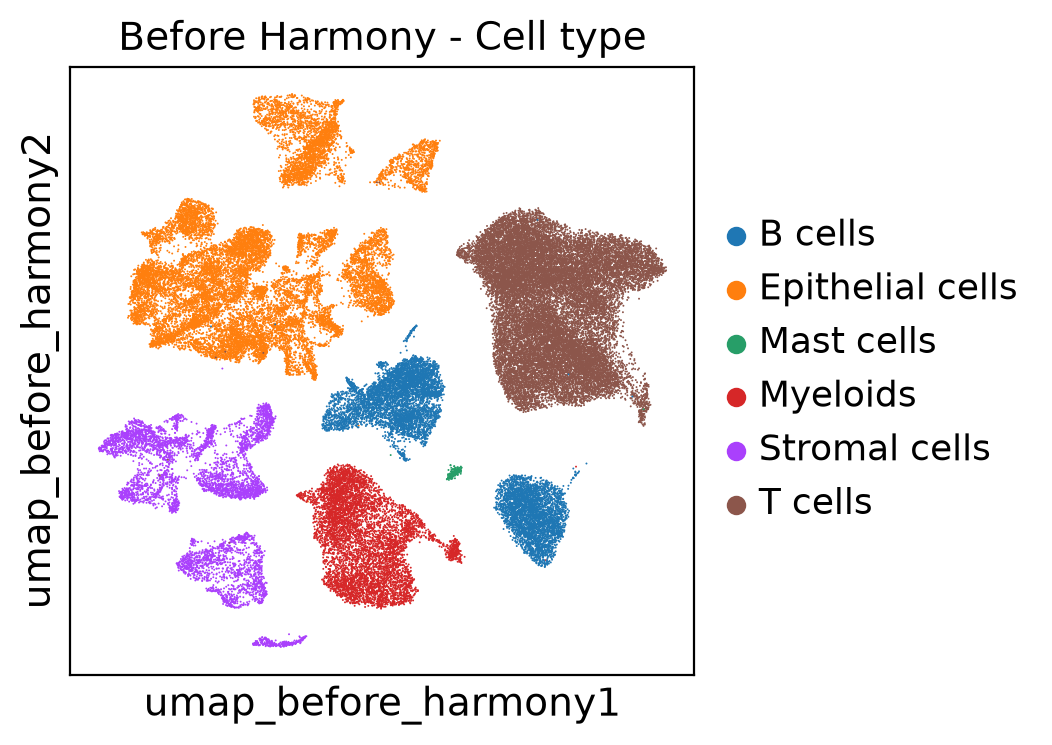

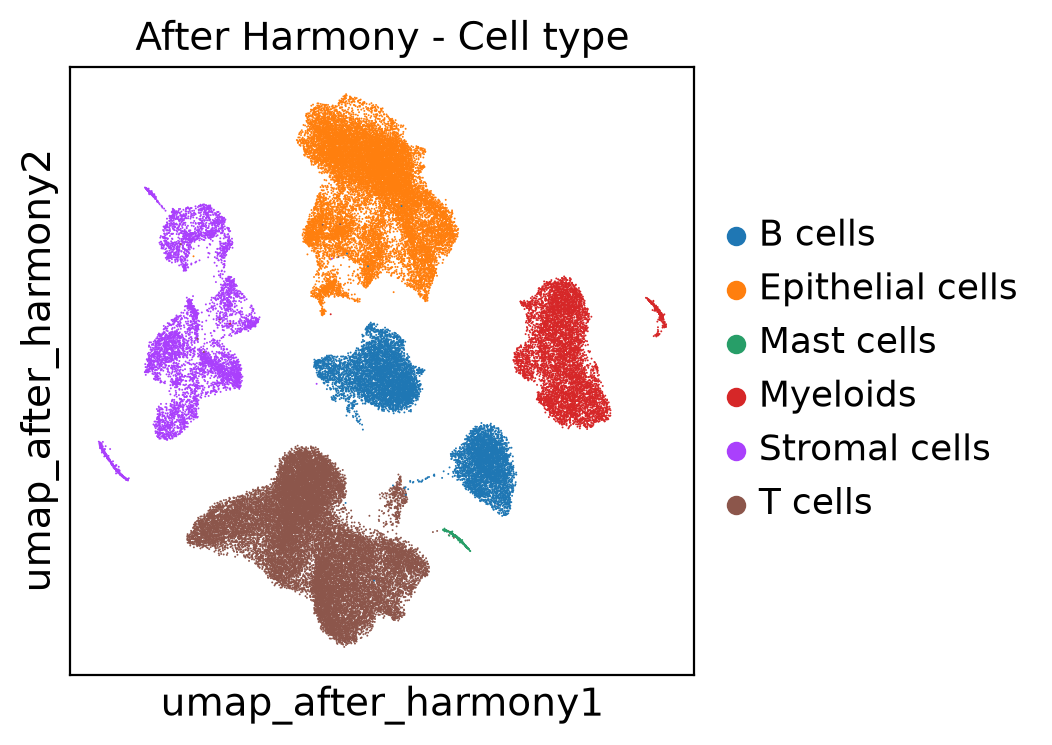

In [21]:
# ============================================================
# 16. Whole dataset UMAP plots: before vs after Harmony
# ============================================================

sc.pl.embedding(
    adata_viz,
    basis="umap_before_harmony",
    color=[celltype_col],
    wspace=0.4,
    ncols=2,
    title=[
        "Before Harmony - Cell type",
    ],
    show=False
)
plt.savefig(os.path.join(FIG_DIR, "umap_before_harmony_overview.png"), dpi=300, bbox_inches="tight")
plt.show()

sc.pl.embedding(
    adata_viz,
    basis="umap_after_harmony",
    color=[celltype_col],
    wspace=0.4,
    ncols=2,
    title=[
        "After Harmony - Cell type",
    ],
    show=False
)
plt.savefig(os.path.join(FIG_DIR, "umap_after_harmony_overview.png"), dpi=300, bbox_inches="tight")
plt.show()

## DL preparation note

For downstream direct cell-level deep learning:
- Use `GSE132465_DL_ready_HVG3000_celllevel.h5ad` as the main input.
- Use `Class` as binary target: Normal = 0, Tumor = 1.
- Use `Cell_type` to subset each cell type separately.
- Use `Patient` as group for patient-aware splitting. If `Patient` is unavailable, use `Sample`.
- Fit any standard scaler only on the training split, then apply it to validation/test cells.
- Do not use Harmony UMAP coordinates as gene-level biomarker model input.

## Raw vs preprocessed UMAP by cell type

This section compares UMAP structure before any preprocessing (raw counts + original annotation) against the DL-ready preprocessed object, colored by `Cell_type`. It uses stratified sampling for a lightweight visualization; set `MAX_CELLS_PER_STAGE = None` to plot all cells.

Raw before preprocessing cells selected: 8,000 / 63,689


normalizing counts per cell


    finished (0:00:01)


extracting highly variable genes


    finished (0:00:03)


...

    using 'X_pca' with n_pcs = 30


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


computing UMAP


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:16)


After preprocessing: 8,000 cells x 3,000 HVGs used for UMAP


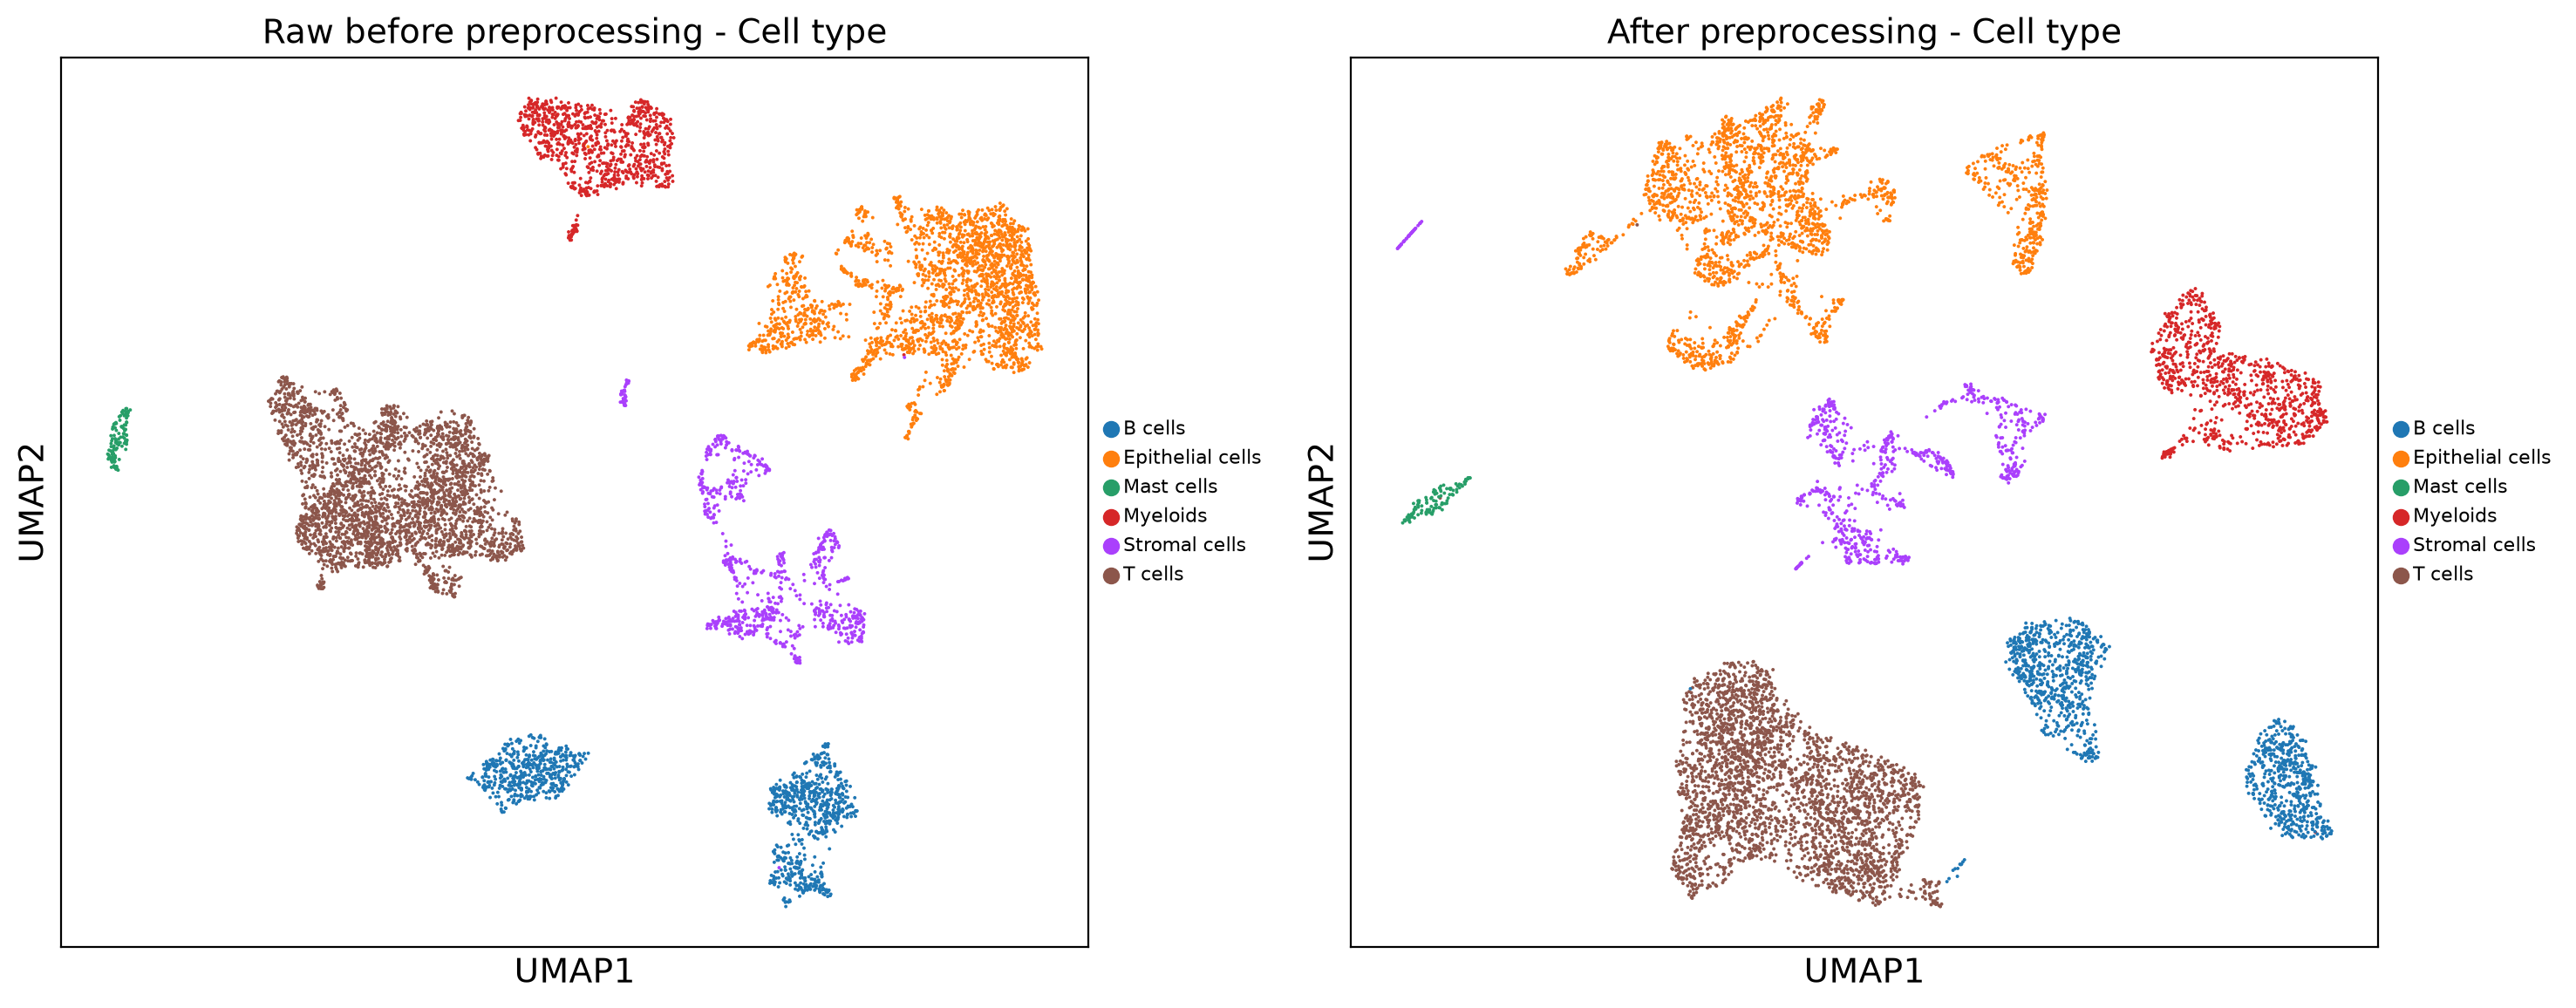

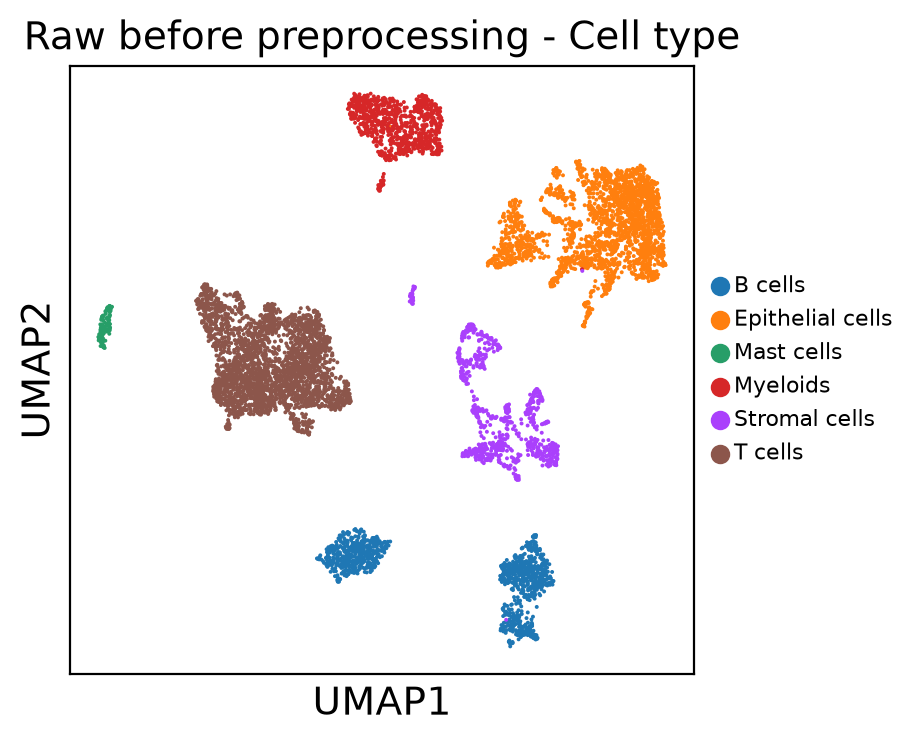

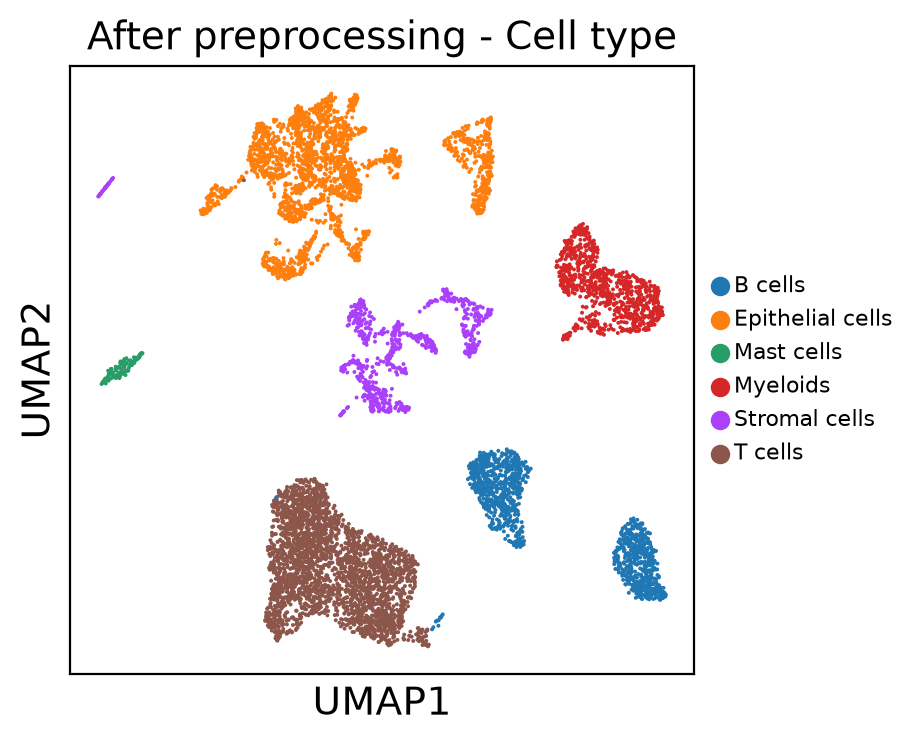

Saved figures:
- gse132465_preprocessing_outputs_before_Xm/figures_before_Xm/umap_raw_vs_preprocessed_celltype.png
- gse132465_preprocessing_outputs_before_Xm/figures_before_Xm/umap_raw_before_preprocessing_celltype.png
- gse132465_preprocessing_outputs_before_Xm/figures_before_Xm/umap_after_preprocessing_celltype.png

Raw selected cell type counts:
Cell_type
T cells             2800
Epithelial cells    2263
B cells             1161
Myeloids             882
Stromal cells        784
Mast cells           110
Name: count, dtype: int64

After preprocessing selected cell type counts:
Cell_type
T cells             2855
Epithelial cells    2205
B cells             1187
Myeloids             875
Stromal cells        768
Mast cells           110
Name: count, dtype: int64


In [1]:
# ============================================================
# 17. Raw before preprocessing vs after preprocessing UMAP by cell type
# ============================================================
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import sparse
from anndata import AnnData

RANDOM_STATE = globals().get("RANDOM_STATE", 42)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")

DATA_DIR = globals().get("DATA_DIR", "..")
COUNT_FILE = globals().get("COUNT_FILE", os.path.join(DATA_DIR, "GSE132465_count_matrix.txt.gz"))
ANNOTATION_FILE = globals().get("ANNOTATION_FILE", os.path.join(DATA_DIR, "GSE132465_annotation.txt.gz"))
OUT_DIR = globals().get("OUT_DIR", "gse132465_preprocessing_outputs_before_Xm")
FIG_DIR = globals().get("FIG_DIR", os.path.join(OUT_DIR, "figures_before_Xm"))
os.makedirs(FIG_DIR, exist_ok=True)

celltype_col = globals().get("celltype_col", "Cell_type")
class_col = globals().get("class_col", "Class")
sample_col = globals().get("sample_col", "Sample")
patient_col = globals().get("patient_col", "Patient")

MAX_CELLS_PER_STAGE = 8000    # set to None to use all cells (slower/heavier)
MIN_CELLS_PER_TYPE = 100      # keeps rare cell types visible when sampling
UMAP_N_HVG = 3000

RAW_VS_PRE_FIG = os.path.join(FIG_DIR, "umap_raw_vs_preprocessed_celltype.png")
RAW_ONLY_FIG = os.path.join(FIG_DIR, "umap_raw_before_preprocessing_celltype.png")
PRE_ONLY_FIG = os.path.join(FIG_DIR, "umap_after_preprocessing_celltype.png")


def stratified_sample_index(obs, group_col, max_cells=None, min_per_group=200, random_state=42):
    """Return obs index values sampled proportionally, with rare groups retained."""
    if max_cells is None or len(obs) <= max_cells:
        return obs.index.to_list()

    counts = obs[group_col].astype(str).value_counts()
    min_per_group = max(1, int(min_per_group))
    quotas = counts.apply(lambda n: min(int(n), min_per_group))

    remaining = int(max_cells) - int(quotas.sum())
    if remaining > 0:
        spare = (counts - quotas).clip(lower=0)
        if spare.sum() > 0:
            raw_extra = spare / spare.sum() * remaining
            extra = np.floor(raw_extra).astype(int).clip(upper=spare)
            quotas = quotas + extra
            remaining = int(max_cells) - int(quotas.sum())
            if remaining > 0:
                fractional = (raw_extra - np.floor(raw_extra)).sort_values(ascending=False)
                for group in fractional.index:
                    if remaining == 0:
                        break
                    if quotas[group] < counts[group]:
                        quotas[group] += 1
                        remaining -= 1
    elif remaining < 0:
        # If the minimum quota alone exceeds max_cells, trim largest groups first.
        over = -remaining
        for group in quotas.sort_values(ascending=False).index:
            if over == 0:
                break
            reducible = max(0, int(quotas[group]) - 1)
            delta = min(reducible, over)
            quotas[group] -= delta
            over -= delta

    sampled = []
    for group, n in quotas.items():
        group_index = obs.index[obs[group_col].astype(str) == group]
        sampled.extend(
            pd.Index(group_index)
            .to_series()
            .sample(n=int(n), random_state=random_state, replace=False)
            .index
            .to_list()
        )
    return sampled


def run_umap_for_visualization(adata_in, stage_name, already_log_normalized=False, hvg_already_subset=False):
    ad = adata_in.copy()
    for col in [celltype_col, class_col, sample_col, patient_col]:
        if col in ad.obs.columns:
            ad.obs[col] = ad.obs[col].astype("category")

    if not already_log_normalized:
        if "counts" not in ad.layers:
            ad.layers["counts"] = ad.X.copy()
        sc.pp.normalize_total(ad, target_sum=1e4)
        sc.pp.log1p(ad)

    if not hvg_already_subset:
        hvg_kwargs = dict(
            n_top_genes=min(UMAP_N_HVG, ad.n_vars),
            flavor="cell_ranger",
            subset=False,
        )
        if patient_col in ad.obs.columns and ad.obs[patient_col].nunique() > 1:
            hvg_kwargs["batch_key"] = patient_col
        try:
            sc.pp.highly_variable_genes(ad, **hvg_kwargs)
        except ValueError as err:
            print(f"{stage_name}: batch-aware cell_ranger HVG failed ({err}); retrying without batch_key.")
            hvg_kwargs.pop("batch_key", None)
            sc.pp.highly_variable_genes(ad, **hvg_kwargs)
        ad = ad[:, ad.var["highly_variable"].values].copy()

    sc.pp.scale(ad, max_value=10)
    n_comps = min(50, ad.n_obs - 1, ad.n_vars - 1)
    n_pcs = min(30, n_comps)
    sc.tl.pca(ad, n_comps=n_comps, svd_solver="arpack", random_state=RANDOM_STATE)
    sc.pp.neighbors(ad, n_neighbors=15, n_pcs=n_pcs, random_state=RANDOM_STATE)
    sc.tl.umap(ad, random_state=RANDOM_STATE)
    print(f"{stage_name}: {ad.n_obs:,} cells x {ad.n_vars:,} HVGs used for UMAP")
    return ad


# ---------- Raw object before preprocessing ----------
raw_meta = pd.read_csv(ANNOTATION_FILE, sep="\t", index_col=0)
for col in [celltype_col, class_col, sample_col, patient_col]:
    if col in raw_meta.columns:
        raw_meta[col] = raw_meta[col].astype("category")

raw_cells = stratified_sample_index(
    raw_meta,
    celltype_col,
    max_cells=MAX_CELLS_PER_STAGE,
    min_per_group=MIN_CELLS_PER_TYPE,
    random_state=RANDOM_STATE,
)
print(f"Raw before preprocessing cells selected: {len(raw_cells):,} / {len(raw_meta):,}")

raw_counts = pd.read_csv(
    COUNT_FILE,
    sep="\t",
    index_col=0,
    usecols=["Index"] + raw_cells,
    dtype={cell: np.float32 for cell in raw_cells},
)
raw_counts = raw_counts.loc[:, raw_cells]
raw_X = sparse.csr_matrix(raw_counts.T.to_numpy(dtype=np.float32, copy=False))
adata_raw_umap = AnnData(
    X=raw_X,
    obs=raw_meta.loc[raw_cells].copy(),
    var=pd.DataFrame(index=raw_counts.index.astype(str)),
)
adata_raw_umap.layers["counts"] = adata_raw_umap.X.copy()
del raw_counts, raw_X

adata_raw_umap = run_umap_for_visualization(
    adata_raw_umap,
    "Raw before preprocessing",
    already_log_normalized=False,
    hvg_already_subset=False,
)

# ---------- Preprocessed DL-ready object ----------
DL_OUT = os.path.join(OUT_DIR, "GSE132465_DL_ready_HVG3000_celllevel.h5ad")
adata_pp_backed = sc.read_h5ad(DL_OUT, backed="r")
pp_obs = adata_pp_backed.obs.copy()
pp_cells = stratified_sample_index(
    pp_obs,
    celltype_col,
    max_cells=MAX_CELLS_PER_STAGE,
    min_per_group=MIN_CELLS_PER_TYPE,
    random_state=RANDOM_STATE,
)
pp_keep = pp_obs.index.isin(pp_cells)
hvg_keep = adata_pp_backed.var["highly_variable"].to_numpy(dtype=bool)
print(f"After preprocessing cells selected: {int(pp_keep.sum()):,} / {adata_pp_backed.n_obs:,}")

adata_pp_umap = adata_pp_backed[pp_keep, hvg_keep].to_memory()
adata_pp_backed.file.close()

adata_pp_umap = run_umap_for_visualization(
    adata_pp_umap,
    "After preprocessing",
    already_log_normalized=True,
    hvg_already_subset=True,
)

# ---------- Plots ----------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(
    adata_raw_umap,
    color=celltype_col,
    ax=axes[0],
    show=False,
    title="Raw before preprocessing - Cell type",
    size=8,
    legend_fontsize=8,
)
sc.pl.umap(
    adata_pp_umap,
    color=celltype_col,
    ax=axes[1],
    show=False,
    title="After preprocessing - Cell type",
    size=8,
    legend_fontsize=8,
)
plt.tight_layout()
plt.savefig(RAW_VS_PRE_FIG, dpi=300, bbox_inches="tight")
plt.show()

sc.pl.umap(
    adata_raw_umap,
    color=celltype_col,
    show=False,
    title="Raw before preprocessing - Cell type",
    size=8,
    legend_fontsize=8,
)
plt.savefig(RAW_ONLY_FIG, dpi=300, bbox_inches="tight")
plt.show()

sc.pl.umap(
    adata_pp_umap,
    color=celltype_col,
    show=False,
    title="After preprocessing - Cell type",
    size=8,
    legend_fontsize=8,
)
plt.savefig(PRE_ONLY_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures:")
print("-", RAW_VS_PRE_FIG)
print("-", RAW_ONLY_FIG)
print("-", PRE_ONLY_FIG)
print("\nRaw selected cell type counts:")
print(adata_raw_umap.obs[celltype_col].value_counts())
print("\nAfter preprocessing selected cell type counts:")
print(adata_pp_umap.obs[celltype_col].value_counts())
